# Full-sweep analysis (S1 speaker, passive detector) — and how it meets the switching studies

`results/full_sweep_v2`: an **S1** speaker heard by a credulous L1 whose detector
ran as a pure observer (`c = ∞`). 297 cells = θ\* ∈ {0.1…0.9} × ψ\* ∈ {honest,
pers+, pers−} × α ∈ {1, 1.5, 2, 2.5, 3, 4, 5, 7, 10, 15, 20}; 200 sims × 150
rounds; `n=1, m=7`. Two scores are recorded every round, **`surp2`** (prior-predictive
surprisal) and **`sus1`** (observation-level suspicion), together with the *full*
L1 and L0 posteriors over an **11-point θ space that includes 0 and 1**.

Three things differ from the switching studies (`switching_analysis.ipynb`):
the detector never switches, there is no vigilant listener, and the θ space has
the two endpoints. Study **A** there (S1 speaker, 9-point θ space, `sus1` only) is
the bridge; study **B** (S2 speaker with an exact model of the switching listener)
is the level-2 counterpart.

**Where the numbers come from.** `experiments/full_sweep/aggregate.py` rebuilds
`results/full_sweep_v2/agg/` from the raw shards in ~10 s: per-round means/sds
(`rounds`), one row per simulation with every fixed-z τ and the belief at
τ−1 (`runs`), dense `S_t`/`V_t` panels for arbitrary stopping rules, and
utterance counts. Its self-check reproduces `S1_headline_table.csv` exactly.
Sections 6–8 also read `results/switching/agg/` and the switching `tau_summary`
tables. Both aggregate sets use the same labels (`inf`/`high`/`low`, `bias = E[θ] − θ*`).

## 0. Setup

In [1]:
import json, os, sys, glob
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
SWEEP_DIR = os.path.join(ROOT, "results", "full_sweep_v2")
AGG_S = os.path.join(SWEEP_DIR, "agg")
AGG_W = os.path.join(ROOT, "results", "switching", "agg")
RAW_W = os.path.join(ROOT, "results")
FIG_DIR = os.path.join(SWEEP_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

SAVE = True           # True  -> every figure also written to FIG_DIR as png

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)
plt.rcParams.update({
    "figure.figsize": (11, 6), "figure.dpi": 110, "savefig.dpi": 160,
    "savefig.bbox": "tight", "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 12, "legend.frameon": False,
})
print("ROOT:", ROOT)

ROOT: C:\Users\onerk\argumentative-awareness


In [2]:
# ---- sweep aggregates ------------------------------------------------------
def _load(d, name):
    return pd.read_parquet(os.path.join(d, f"{name}.parquet"))

RS = _load(AGG_S, "rounds")         # per (theta*, psi*, alpha, round)
RUS = _load(AGG_S, "runs")          # per simulation
UTS = _load(AGG_S, "utterances")
META_S = json.load(open(os.path.join(AGG_S, "meta.json"), encoding="utf-8"))
PANEL = {k: _load(AGG_S, f"panels_{k}").to_numpy() for k in ("S_surp2", "V_surp2", "S_sus1", "V_sus1")}

# ---- switching aggregates (sections 6-8) ------------------------------------
HAVE_SWITCH = os.path.isdir(AGG_W)
if HAVE_SWITCH:
    RW = _load(AGG_W, "rounds")
    RUW = _load(AGG_W, "runs")
    TAUW = pd.concat([pd.read_parquet(os.path.join(RAW_W, f"switching_{s}", "tau_summary.parquet"))
                      for s in ("A", "B", "Fvig", "Fcred")], ignore_index=True)
else:
    print("switching aggregates not found -- sections 6-8 will be skipped")

for nm, df in [("sweep rounds", RS), ("sweep runs", RUS)] + ([("switch rounds", RW), ("switch tau", TAUW)] if HAVE_SWITCH else []):
    print(f"{nm:14s} {len(df):>10,} rows")
print("panels:", {k: v.shape for k, v in PANEL.items()})

sweep rounds       44,550 rows
sweep runs         59,400 rows
switch rounds   1,296,000 rows
switch tau        864,000 rows
panels: {'S_surp2': (59400, 150), 'V_surp2': (59400, 150), 'S_sus1': (59400, 150), 'V_sus1': (59400, 150)}


In [3]:
# ---- constants, labels, palette ------------------------------------------
THETA_SPACE = np.array(META_S["theta_space"], dtype=float)   # 11 points incl. 0 and 1
THETAS = sorted(RS.theta_star.unique())                          # 9 true values
ALPHAS = sorted(RS.alpha.unique())                               # 11 values, to 20
CS = [float(c) for c in META_S["c_list"]]                        # 2 .. 5
SCORES = ["surp2", "sus1"]
PSIS = ["inf", "high", "low"]
T_MAX = int(RS["round"].max())
ROUNDS = np.arange(1, T_MAX + 1)

PSI_LABEL = {"inf": "honest", "high": "pers+", "low": "pers−"}
SCORE_LABEL = {"surp2": "surp2 (prior-predictive surprisal)", "sus1": "sus₁ (observation-level suspicion)"}
SCORE_SHORT = {"surp2": "surp2", "sus1": "sus₁"}
COL = {"surp2": "#2b6cb0", "sus1": "#c0392b", "L1": "#d1751f", "L0": "#7a4bbf",
       "sweep": "#c0392b", "A": "#888888", "B": "#2f8f4e", "Fvig": "#2b6cb0", "Fcred": "#d1751f",
       "cred": "#d1751f", "vig": "#2b6cb0", "switch": "#2f8f4e"}
PSI_COL = {"inf": "#2f8f4e", "high": "#d1751f", "low": "#2b6cb0"}
CMAP_SEQ, CMAP_DIV = "viridis", "RdBu_r"

def _cmap_colors(vals, cmap, top=0.85):
    cm = plt.get_cmap(cmap)
    return {v: cm(i / max(len(vals) - 1, 1) * top) for i, v in enumerate(vals)}
ACOL, TCOL, CCOL = _cmap_colors(ALPHAS, "plasma"), _cmap_colors(THETAS, "viridis", 0.9), _cmap_colors(CS, "cividis")

FOCUS = dict(theta=0.3, alpha=3.0, c=3.5)
print(f"grid: {len(THETAS)} theta* x {len(PSIS)} psi* x {len(ALPHAS)} alpha; c list {CS}; theta space {list(THETA_SPACE)}")
print("FOCUS:", FOCUS)

grid: 9 theta* x 3 psi* x 11 alpha; c list [2.0, 2.5, 3.0, 3.5, 4.0, 5.0]; theta space [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
FOCUS: {'theta': 0.3, 'alpha': 3.0, 'c': 3.5}


In [4]:
# ---- helpers ---------------------------------------------------------------
def sel(df, **kw):
    '''Filter by equality, or by membership when the value is a list/tuple.'''
    m = np.ones(len(df), dtype=bool)
    for k, v in kw.items():
        if v is None:
            continue
        col = df[k].to_numpy()
        m &= np.isin(col, list(v)) if isinstance(v, (list, tuple, set, np.ndarray)) else (col == v)
    return df[m]

def finish(ax, ttl="", xlabel="", ylabel="", legend=True, save_as=None, **lg):
    ax.set_title(ttl); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    if legend and ax.get_legend_handles_labels()[0]:
        ax.legend(**lg)
    fig = ax.get_figure(); fig.tight_layout()
    if SAVE and save_as:
        fig.savefig(os.path.join(FIG_DIR, f"{save_as}.png"))
    return ax

def save_fig(fig, name):
    fig.tight_layout()
    if SAVE:
        fig.savefig(os.path.join(FIG_DIR, f"{name}.png"))

def band(ax, x, mu, sd, n, color, label=None, z=1.96, **kw):
    mu, sd, n = np.asarray(mu, float), np.asarray(sd, float), np.asarray(n, float)
    ax.plot(x, mu, color=color, label=label, **kw)
    sem = sd / np.sqrt(np.maximum(n, 1))
    ax.fill_between(x, mu - z * sem, mu + z * sem, color=color, alpha=0.18, lw=0)

def heat(ax, M, xticks, yticks, xlabel, ylabel, title, cmap=CMAP_SEQ, vmin=None, vmax=None,
         fmt="{:.2f}", cbar_label="", txt_thresh=0.55, fontsize=8):
    im = ax.imshow(M, cmap=cmap, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(xticks)), [f"{t:g}" if isinstance(t, (int, float, np.floating)) else str(t) for t in xticks])
    ax.set_yticks(range(len(yticks)), [f"{t:g}" if isinstance(t, (int, float, np.floating)) else str(t) for t in yticks])
    ax.grid(False)
    lo = np.nanmin(M) if vmin is None else vmin
    hi = np.nanmax(M) if vmax is None else vmax
    rng = (hi - lo) or 1.0
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            if np.isfinite(v):
                ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=fontsize,
                        color="white" if abs(v - lo) / rng > txt_thresh else "black")
    cb = ax.get_figure().colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    if cbar_label:
        cb.set_label(cbar_label)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    return im

def alpha_axis(ax, alphas=ALPHAS):
    ax.set_xscale("log"); ax.set_xticks(alphas, [f"{a:g}" for a in alphas]); ax.set_xlabel("α")

# ---- detection rates from per-run tau (fixed-z rule) ------------------------
def tau_col(score, c):
    return f"tau_{score}_c{c:g}"

def hit(df, score, c, horizon=None):
    t = df[tau_col(score, c)].to_numpy()
    return ((t > 0) & (t <= horizon)).astype(float) if horizon is not None else (t > 0).astype(float)

def rate_by(keys, score, c, horizon=None, **kw):
    d = sel(RUS, **kw).copy()
    d["hit"] = hit(d, score, c, horizon)
    return d.groupby(keys, observed=True)["hit"].mean().reset_index(name="rate")

def fa_power(score, c, horizon=None, **kw):
    d = sel(RUS, **kw)
    return (hit(d[d.psi_star == "inf"], score, c, horizon).mean(),
            hit(d[d.psi_star != "inf"], score, c, horizon).mean())

def survival(tau, T=T_MAX):
    tv = np.asarray(tau); n = len(tv)
    cnt = np.bincount(tv[tv > 0].astype(int), minlength=T + 2)[:T + 1]
    return 1.0 - np.cumsum(cnt) / max(n, 1)

# ---- raw-row access for deep dives ------------------------------------------
_CELL_INDEX = None
def _cell_index():
    '''(theta*, psi*, alpha) -> cell_id, read once from the tiny simulations/ shards.'''
    global _CELL_INDEX
    if _CELL_INDEX is None:
        parts = [pd.read_parquet(p, columns=["cell_id", "theta_star", "psi_true", "alpha"]).iloc[[0]]
                 for p in sorted(glob.glob(os.path.join(SWEEP_DIR, "simulations", "cell=*", "part.parquet")))]
        d = pd.concat(parts, ignore_index=True)
        d["psi_star"] = d["psi_true"].map(META_S["psi_map"])
        _CELL_INDEX = {(float(r.theta_star), r.psi_star, float(r.alpha)): int(r.cell_id) for r in d.itertuples()}
    return _CELL_INDEX

def load_sweep_cell(theta_star, psi_star, alpha, columns=None):
    '''Raw per-round rows of one sweep cell (psi_star in switching labels).'''
    cid = _cell_index().get((float(theta_star), psi_star, float(alpha)))
    if cid is None:
        raise ValueError(f"no sweep cell for theta*={theta_star} psi*={psi_star} alpha={alpha}")
    return pd.read_parquet(os.path.join(SWEEP_DIR, "trajectories", f"cell={cid:04d}", "part.parquet"), columns=columns)

print("helpers ready")

helpers ready


## 1. Diagnostics

Completeness, the world model, and — most importantly — whether the detector's
null is honest: under the honest S1 the per-round score should average zero,
its empirical variance should match the analytic σ², and Var[Sus(t)] should
fall like 1/t.

In [5]:
# 1.1 completeness
cfg = json.load(open(os.path.join(SWEEP_DIR, "run_config.json"), encoding="utf-8"))
print(f"status={cfg['status']}  git={cfg['git_hash'][:7]}  built={cfg['run_date_utc']}")
print(f"cells={cfg['grid']['n_cells']}  sims/cell={cfg['grid']['n_sims_per_cell']}  rounds={cfg['grid']['rounds']}")
print(f"runs table: {len(RUS):,} rows  |  rounds table: {len(RS):,} rows  |  n per (cell, round): {int(RS.n.min())}..{int(RS.n.max())}")
assert cfg["status"] == "complete" and len(RUS) == cfg["grid"]["n_cells"] * cfg["grid"]["n_sims_per_cell"]
assert RS.n.min() == RS.n.max() == cfg["grid"]["n_sims_per_cell"]
print("OK: complete, every cell present")

status=complete  git=6cf7339  built=2026-09-09T15:06:03Z
cells=297  sims/cell=200  rounds=150
runs table: 59,400 rows  |  rounds table: 44,550 rows  |  n per (cell, round): 200..200
OK: complete, every cell present


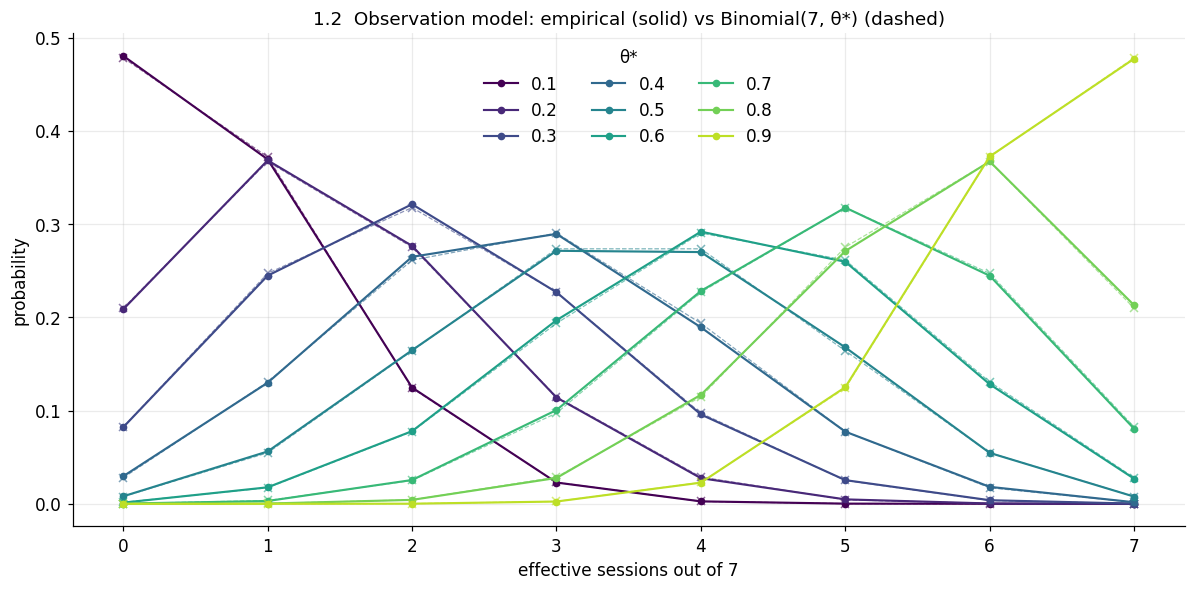

In [6]:
# 1.2 observation model: effective-session counts vs Binomial(7, theta*)
from scipy.stats import binom
fig, ax = plt.subplots(figsize=(11, 5.5))
u = sel(UTS, alpha=FOCUS["alpha"], psi_star="inf")
for th in THETAS:
    d = u[u.theta_star == th].groupby("obs_count")["n"].sum()
    p = (d / d.sum()).reindex(range(8), fill_value=0)
    ax.plot(range(8), p.values, "o-", color=TCOL[th], ms=4, lw=1.4, label=f"{th:g}")
    ax.plot(range(8), binom.pmf(range(8), 7, th), "x--", color=TCOL[th], ms=5, lw=0.8, alpha=0.6)
finish(ax, "1.2  Observation model: empirical (solid) vs Binomial(7, θ*) (dashed)",
       "effective sessions out of 7", "probability", ncol=3, title="θ*", save_as="D1_world_check")
plt.show()

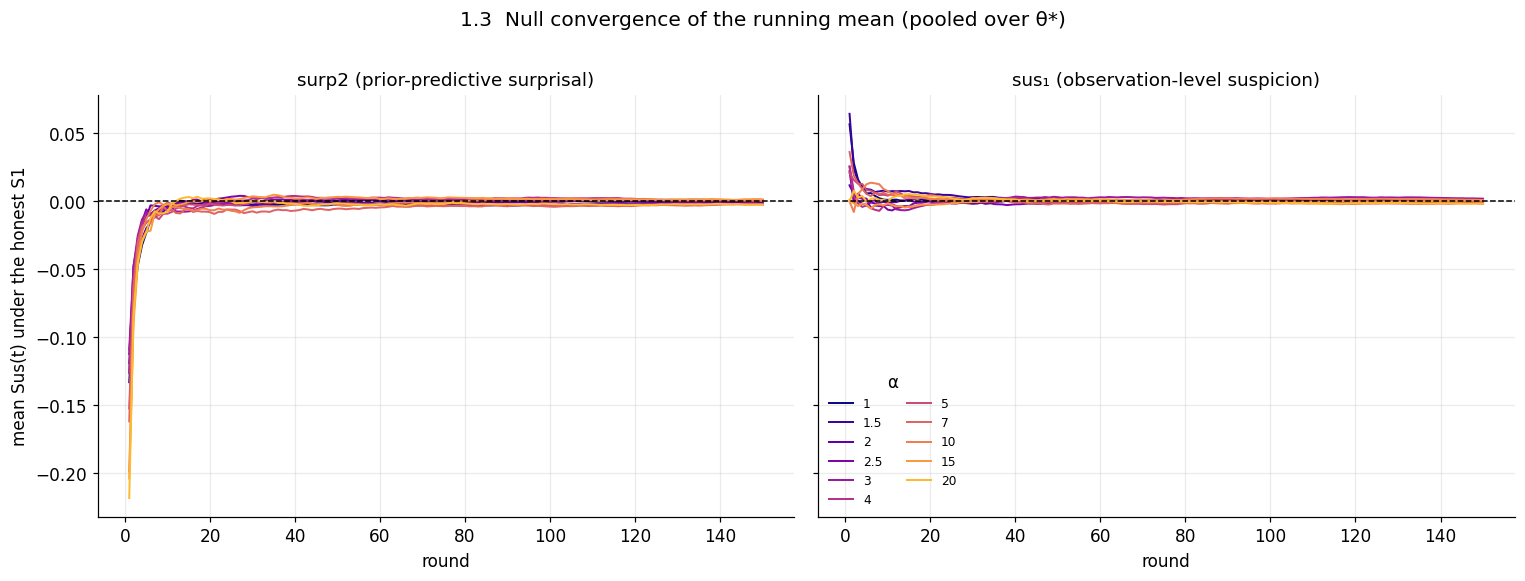

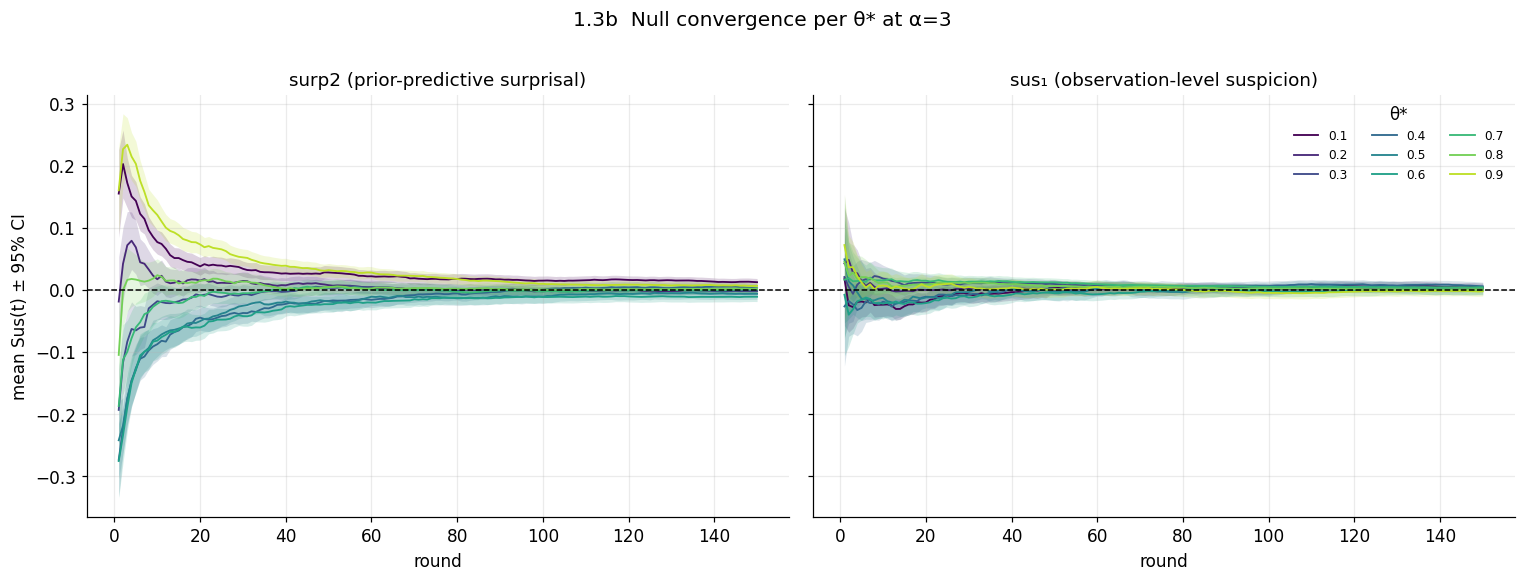

In [7]:
# 1.3 null convergence of Sus(t): pooled over theta*, one line per alpha
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for ax, sc in zip(axes, SCORES):
    for a in ALPHAS:
        q = sel(RS, psi_star="inf", alpha=a).groupby("round")[f"{sc}_Sus"].mean()
        ax.plot(q.index, q.values, color=ACOL[a], lw=1.3, label=f"{a:g}")
    ax.axhline(0, color="k", lw=1, ls="--")
    ax.set_title(SCORE_LABEL[sc]); ax.set_xlabel("round")
axes[0].set_ylabel("mean Sus(t) under the honest S1")
axes[1].legend(title="α", ncol=2, fontsize=8)
fig.suptitle("1.3  Null convergence of the running mean (pooled over θ*)", y=1.01)
save_fig(fig, "D2_null_convergence"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for ax, sc in zip(axes, SCORES):
    for th in THETAS:
        q = sel(RS, psi_star="inf", alpha=FOCUS["alpha"], theta_star=th).sort_values("round")
        band(ax, q["round"], q[f"{sc}_Sus"], q[f"{sc}_Sus_sd"], q.n, TCOL[th], label=f"{th:g}", lw=1.2)
    ax.axhline(0, color="k", lw=1, ls="--")
    ax.set_title(SCORE_LABEL[sc]); ax.set_xlabel("round")
axes[0].set_ylabel("mean Sus(t) ± 95% CI")
axes[1].legend(title="θ*", ncol=3, fontsize=8)
fig.suptitle(f"1.3b  Null convergence per θ* at α={FOCUS['alpha']:g}", y=1.01)
save_fig(fig, "D2b_null_convergence_theta"); plt.show()

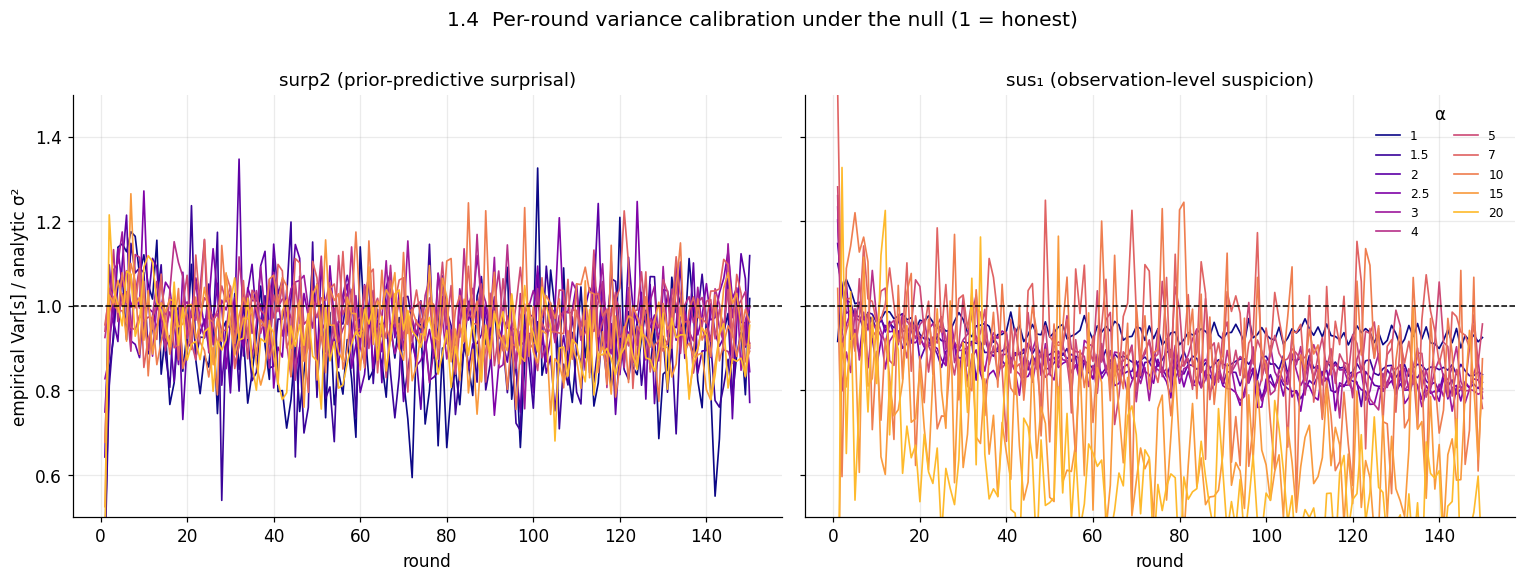

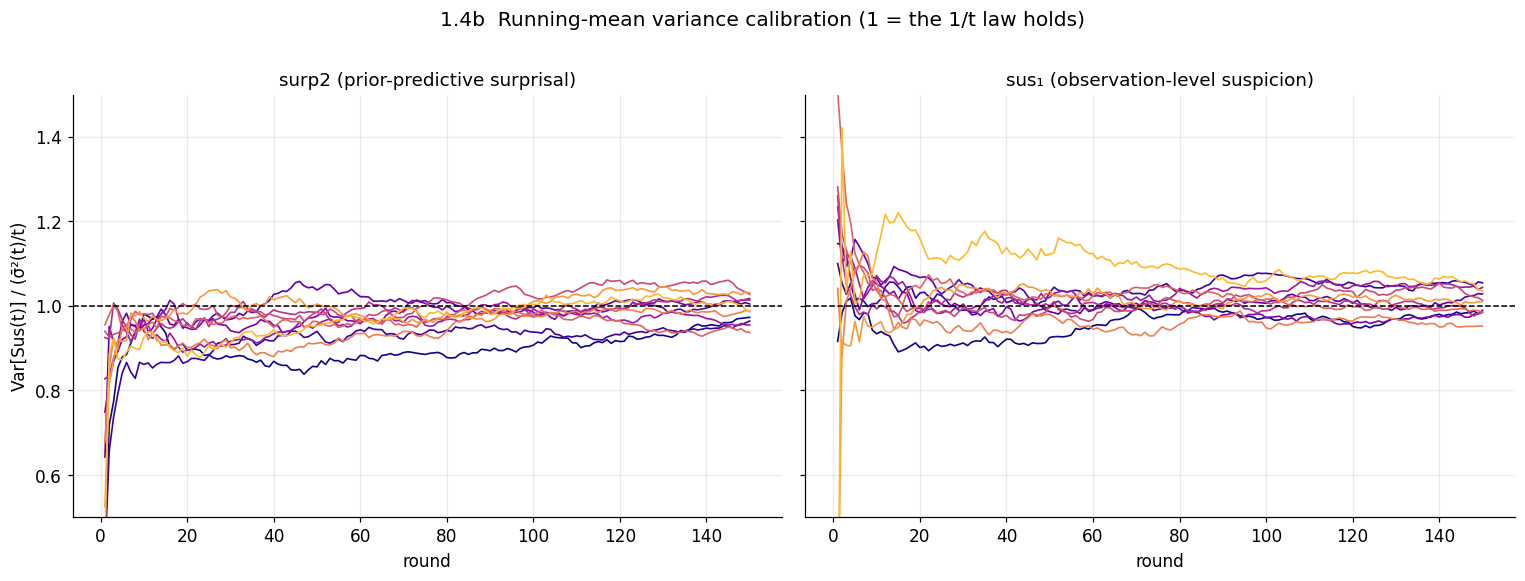

pooled Var/sigma^2 under the null: {'surp2': 0.999, 'sus₁': 1.001}


In [8]:
# 1.4 variance calibration: empirical per-round Var[score] / analytic sigma^2, and the
# running-mean version Var[Sus(t)] / (mean sigma_bar^2 / t).  Both should sit at 1.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for ax, sc in zip(axes, SCORES):
    for a in ALPHAS:
        q = sel(RS, psi_star="inf", alpha=a).groupby("round")[[f"{sc}_score_sd", f"{sc}_sigma2"]].mean()
        ax.plot(q.index, q[f"{sc}_score_sd"] ** 2 / q[f"{sc}_sigma2"], color=ACOL[a], lw=1.1, label=f"{a:g}")
    ax.axhline(1, color="k", lw=1, ls="--"); ax.set_ylim(0.5, 1.5)
    ax.set_title(SCORE_LABEL[sc]); ax.set_xlabel("round")
axes[0].set_ylabel("empirical Var[s] / analytic σ²")
axes[1].legend(title="α", ncol=2, fontsize=8)
fig.suptitle("1.4  Per-round variance calibration under the null (1 = honest)", y=1.01)
save_fig(fig, "D3_variance_calibration"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for ax, sc in zip(axes, SCORES):
    for a in ALPHAS:
        q = sel(RS, psi_star="inf", alpha=a).groupby("round")[[f"{sc}_Sus_sd", f"{sc}_sigma_bar"]].mean()
        ax.plot(q.index, q[f"{sc}_Sus_sd"] ** 2 / (q[f"{sc}_sigma_bar"] ** 2 / q.index), color=ACOL[a], lw=1.1, label=f"{a:g}")
    ax.axhline(1, color="k", lw=1, ls="--"); ax.set_ylim(0.5, 1.5)
    ax.set_title(SCORE_LABEL[sc]); ax.set_xlabel("round")
axes[0].set_ylabel("Var[Sus(t)] / (σ̄²(t)/t)")
fig.suptitle("1.4b  Running-mean variance calibration (1 = the 1/t law holds)", y=1.01)
save_fig(fig, "D3b_running_variance"); plt.show()

pooled = {sc: float((sel(RS, psi_star='inf')[f'{sc}_score_sd'] ** 2 / sel(RS, psi_star='inf')[f'{sc}_sigma2']).mean()) for sc in SCORES}
print("pooled Var/sigma^2 under the null:", {SCORE_SHORT[k]: round(v, 3) for k, v in pooled.items()})

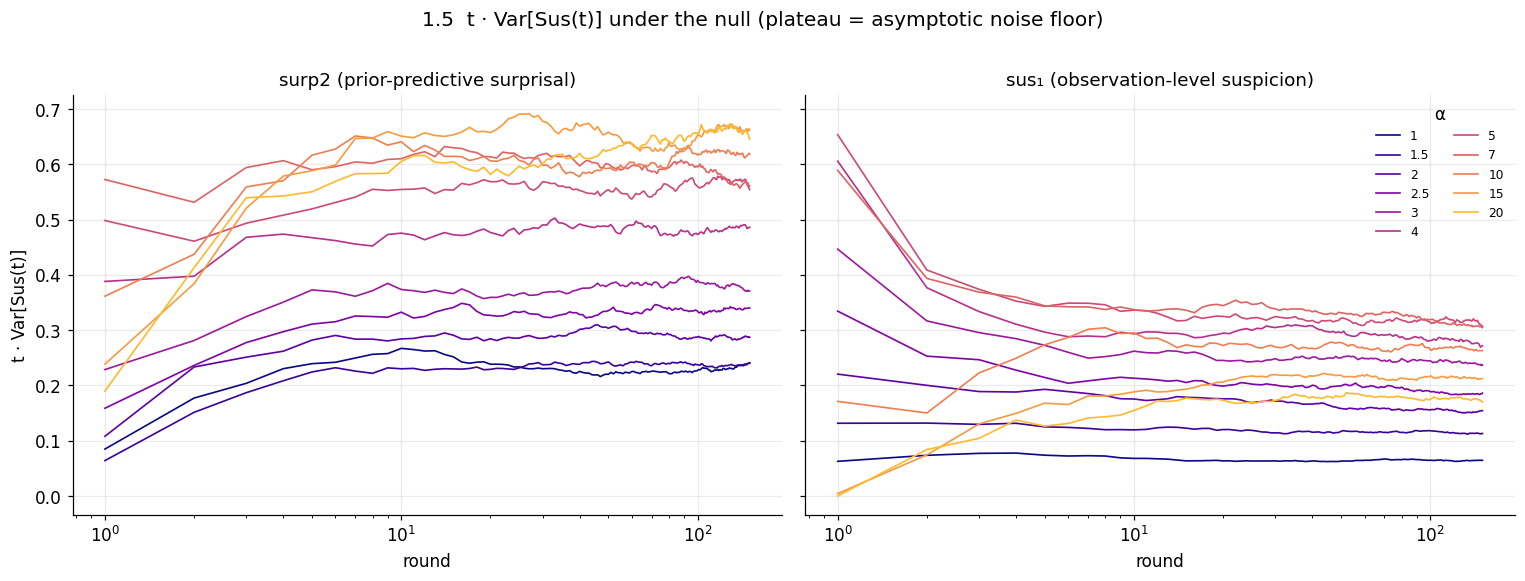

mean Sus(150) under the null, by alpha:


C:\Users\onerk\AppData\Local\Temp\ipykernel_34272\706541852.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  display(sel(RS, psi_star="inf")[RS["round"] == T_MAX].groupby("alpha")[[f"{sc}_Sus" for sc in SCORES]].mean().round(4).T)


alpha,1.0,1.5,2.0,2.5,3.0,4.0,5.0,7.0,10.0,15.0,20.0
surp2_Sus,-0.0019,-0.0004,-0.0009,0.0009,0.0005,0.0004,-0.0024,-0.0023,0.0003,0.0012,-0.0025
sus1_Sus,0.0003,0.0011,0.0006,-0.0003,0.0018,0.0002,-0.0009,-0.0019,0.0008,0.0004,-0.0018


In [9]:
# 1.5 Var[Sus(t)] * t against round: a flat line means the 1/t scaling holds
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for ax, sc in zip(axes, SCORES):
    for a in ALPHAS:
        q = sel(RS, psi_star="inf", alpha=a).groupby("round")[f"{sc}_Sus_sd"].mean()
        ax.plot(q.index, q.values ** 2 * q.index, color=ACOL[a], lw=1.1, label=f"{a:g}")
    ax.set_xscale("log"); ax.set_title(SCORE_LABEL[sc]); ax.set_xlabel("round")
axes[0].set_ylabel("t · Var[Sus(t)]")
axes[1].legend(title="α", ncol=2, fontsize=8)
fig.suptitle("1.5  t · Var[Sus(t)] under the null (plateau = asymptotic noise floor)", y=1.01)
save_fig(fig, "D4_t_var_scaling"); plt.show()

print("mean Sus(150) under the null, by alpha:")
display(sel(RS, psi_star="inf")[RS["round"] == T_MAX].groupby("alpha")[[f"{sc}_Sus" for sc in SCORES]].mean().round(4).T)

## 2. What the two scores see

Before any stopping rule: how far apart are the null and the alternative at
the horizon, where in (θ\*, α) does each score separate them, and are the two
scores measuring the same thing?

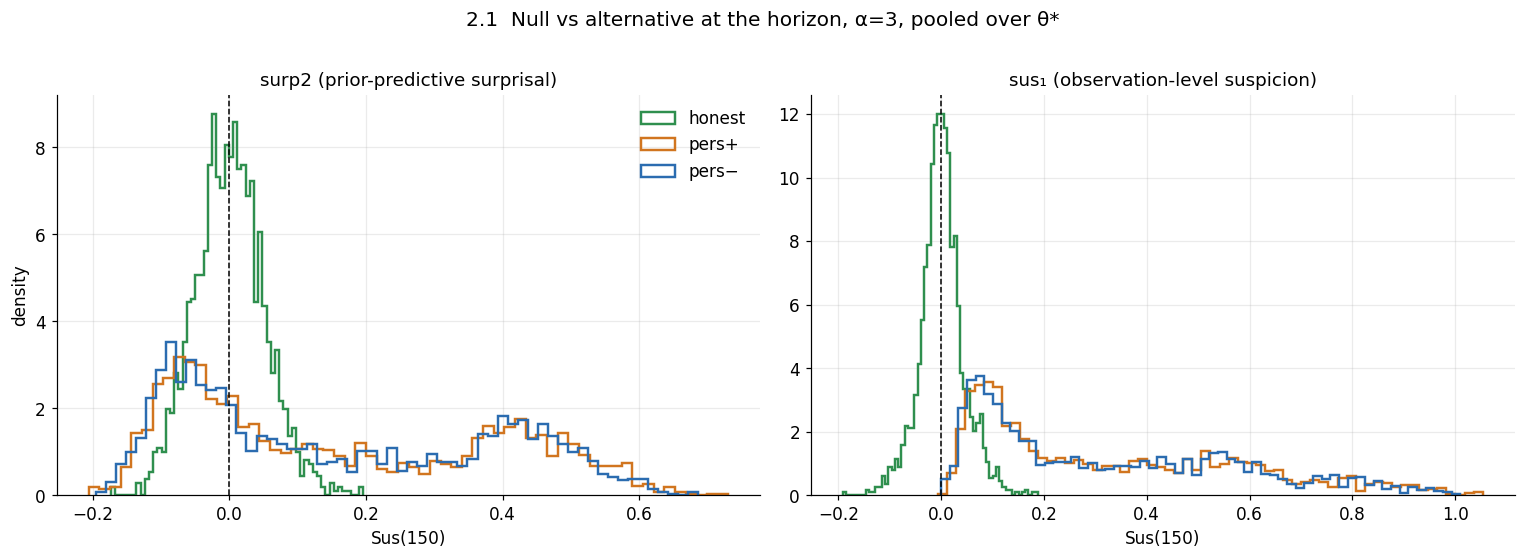

In [10]:
# 2.1 separation at t = 150, one panel per score, at the focus alpha
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, sc in zip(axes, SCORES):
    for psi in PSIS:
        x = sel(RUS, alpha=FOCUS["alpha"], psi_star=psi)[f"Sus150_{sc}"]
        ax.hist(x, bins=60, histtype="step", density=True, lw=1.6, color=PSI_COL[psi], label=PSI_LABEL[psi])
    ax.axvline(0, color="k", lw=1, ls="--")
    ax.set_title(SCORE_LABEL[sc]); ax.set_xlabel("Sus(150)")
axes[0].set_ylabel("density"); axes[0].legend()
fig.suptitle(f"2.1  Null vs alternative at the horizon, α={FOCUS['alpha']:g}, pooled over θ*", y=1.01)
save_fig(fig, "S1_separation"); plt.show()

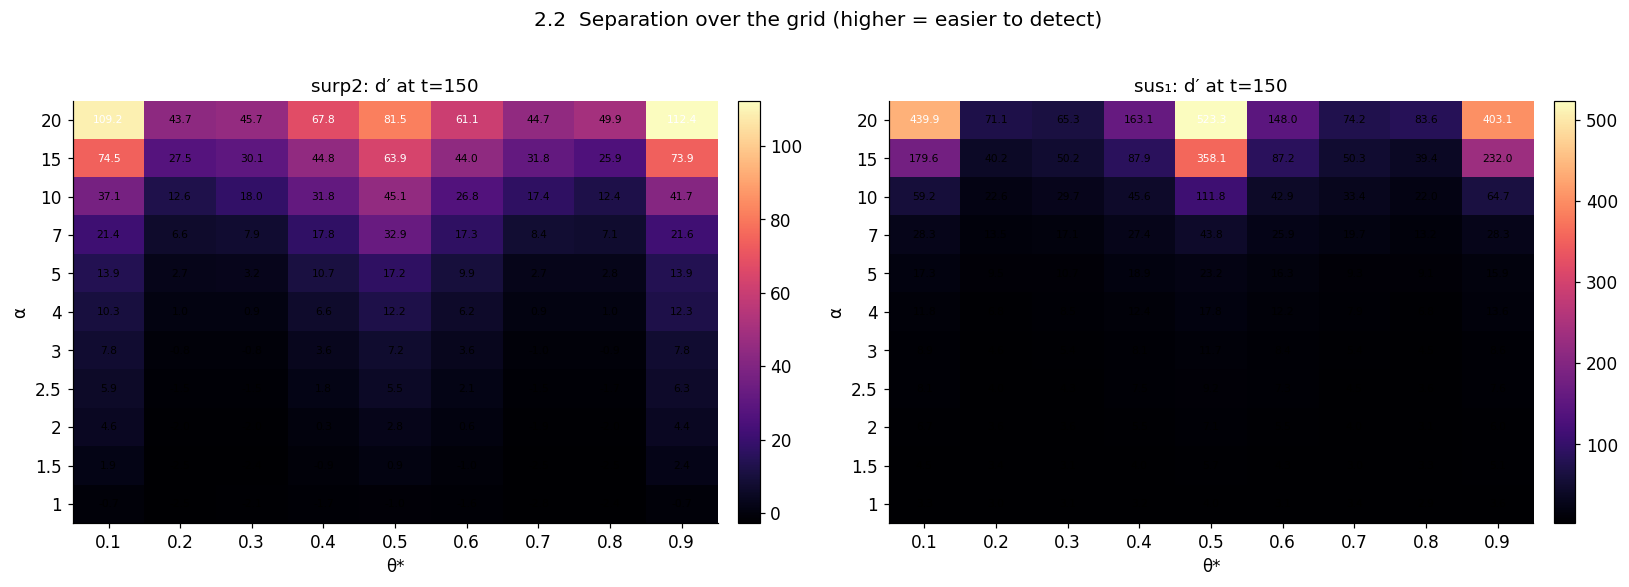

median d': {'surp2': 6.24, 'sus₁': 9.34}


In [11]:
# 2.2 d' = (E[Sus|alt] - E[Sus|null]) / sd(Sus|null) at t=150 over the grid
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
DP = {}
for ax, sc in zip(axes, SCORES):
    M = np.full((len(ALPHAS), len(THETAS)), np.nan)
    for i, a in enumerate(ALPHAS):
        for j, th in enumerate(THETAS):
            n = sel(RUS, alpha=a, theta_star=th, psi_star="inf")[f"Sus150_{sc}"]
            p = sel(RUS, alpha=a, theta_star=th, psi_star=["high", "low"])[f"Sus150_{sc}"]
            if n.std(ddof=1) > 0:
                M[i, j] = (p.mean() - n.mean()) / n.std(ddof=1)
    DP[sc] = M
    heat(ax, M, THETAS, ALPHAS, "θ*", "α", f"{SCORE_SHORT[sc]}: d′ at t=150", cmap="magma", fmt="{:.1f}", fontsize=7)
fig.suptitle("2.2  Separation over the grid (higher = easier to detect)", y=1.02)
save_fig(fig, "S2_dprime"); plt.show()
print("median d':", {SCORE_SHORT[s]: round(float(np.nanmedian(DP[s])), 2) for s in SCORES})

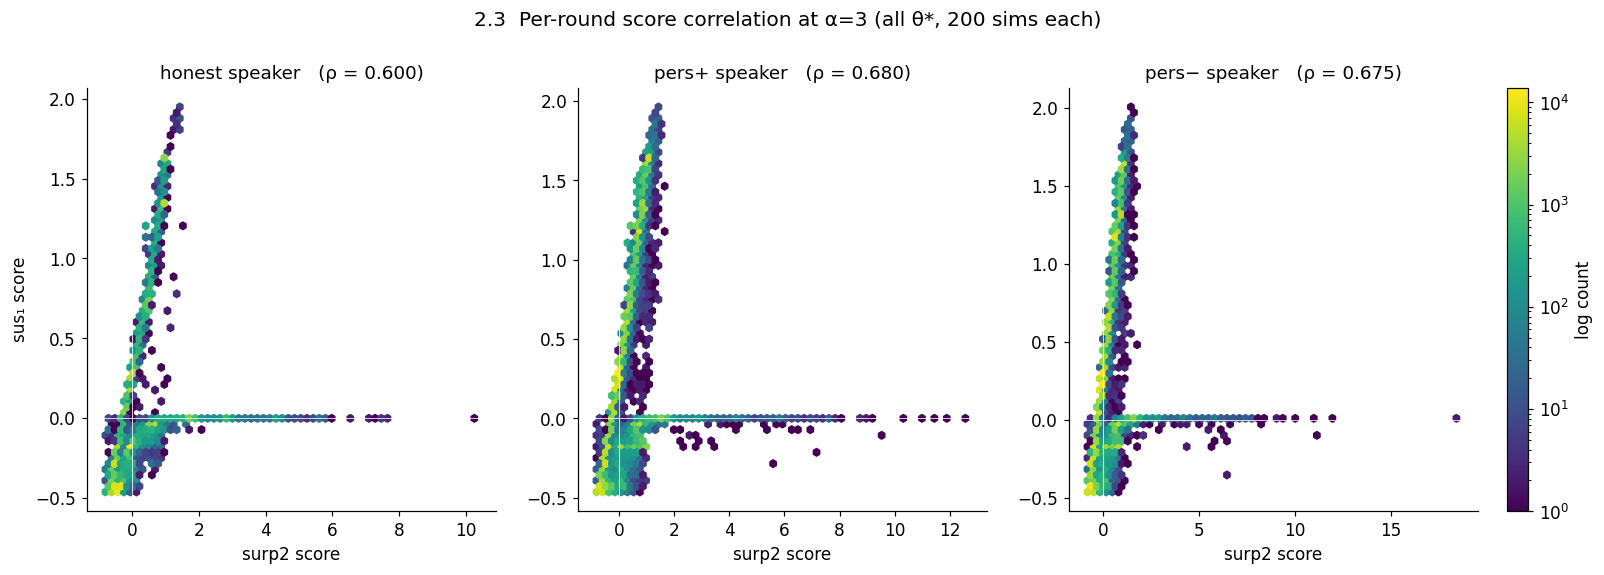

In [12]:
# 2.3 are the two scores measuring the same thing?  Per-round correlation from
# raw rows of the focus alpha (one cell per psi*, all theta*)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, psi in zip(axes, PSIS):
    parts = [load_sweep_cell(th, psi, FOCUS["alpha"], columns=["surp2_score", "sus1_score"]) for th in THETAS]
    d = pd.concat(parts, ignore_index=True)
    rho = float(np.corrcoef(d.surp2_score, d.sus1_score)[0, 1])
    hb = ax.hexbin(d.surp2_score, d.sus1_score, gridsize=60, cmap="viridis", bins="log", mincnt=1)
    ax.axhline(0, color="w", lw=0.5); ax.axvline(0, color="w", lw=0.5); ax.grid(False)
    ax.set_title(f"{PSI_LABEL[psi]} speaker   (ρ = {rho:.3f})"); ax.set_xlabel("surp2 score")
axes[0].set_ylabel("sus₁ score")
fig.colorbar(hb, ax=axes, fraction=0.02, pad=0.02, label="log count")
fig.suptitle(f"2.3  Per-round score correlation at α={FOCUS['alpha']:g} (all θ*, 200 sims each)", y=1.02)
if SAVE: fig.savefig(os.path.join(FIG_DIR, "S3_score_correlation.png"))
plt.show()

## 3. Detection with the fixed-z rule

The rule in production: fire at the first t with Sus(t) > c·σ̄(t)/√t. Rates are
computed from each run's τ. The first cell reproduces the published headline
table (which excluded α=1) before extending it.

In [13]:
# 3.1 headline: false alarm (honest) and power (mean of pers+/pers-) by (score, c)
def headline(df):
    rows = []
    for sc in SCORES:
        for c in CS:
            h = df[df.psi_star == "inf"]; p = df[df.psi_star == "high"]; m = df[df.psi_star == "low"]
            fa, tp, tm = hit(h, sc, c).mean(), hit(p, sc, c).mean(), hit(m, sc, c).mean()
            rows.append(dict(score=SCORE_SHORT[sc], c=c, false_alarm=fa, power_pers_plus=tp,
                             power_pers_minus=tm, power=0.5 * (tp + tm), youden=0.5 * (tp + tm) - fa))
    return pd.DataFrame(rows)

pub = pd.read_csv(os.path.join(SWEEP_DIR, "analyses", "substantive", "S1_headline_table.csv"))
chk = headline(RUS[RUS.alpha != 1.0])
for _, r in pub.iterrows():
    mine = chk[(chk.score == SCORE_SHORT[r.score]) & (chk.c == r.c)].iloc[0]
    assert abs(mine.false_alarm - r.FPR) < 5e-4 and abs(mine.power_pers_plus - r["TPR_pers+"]) < 5e-4
print("self-check PASSED: reproduces S1_headline_table.csv (alpha=1 excluded)\n")
HL = headline(RUS)
print("All alpha included:")
display(HL.round(3).pivot(index="c", columns="score", values=["false_alarm", "power", "youden"]))

self-check PASSED: reproduces S1_headline_table.csv (alpha=1 excluded)

All alpha included:


false_alarm         power        youden       
score       surp2   sus₁  surp2   sus₁  surp2   sus₁
c                                                   
2.0         0.233  0.215  0.679  0.994  0.446  0.778
2.5         0.121  0.121  0.639  0.981  0.518  0.860
3.0         0.069  0.061  0.609  0.954  0.539  0.894
3.5         0.035  0.028  0.579  0.912  0.544  0.884
4.0         0.020  0.017  0.553  0.859  0.533  0.842
5.0         0.006  0.010  0.508  0.759  0.502  0.748

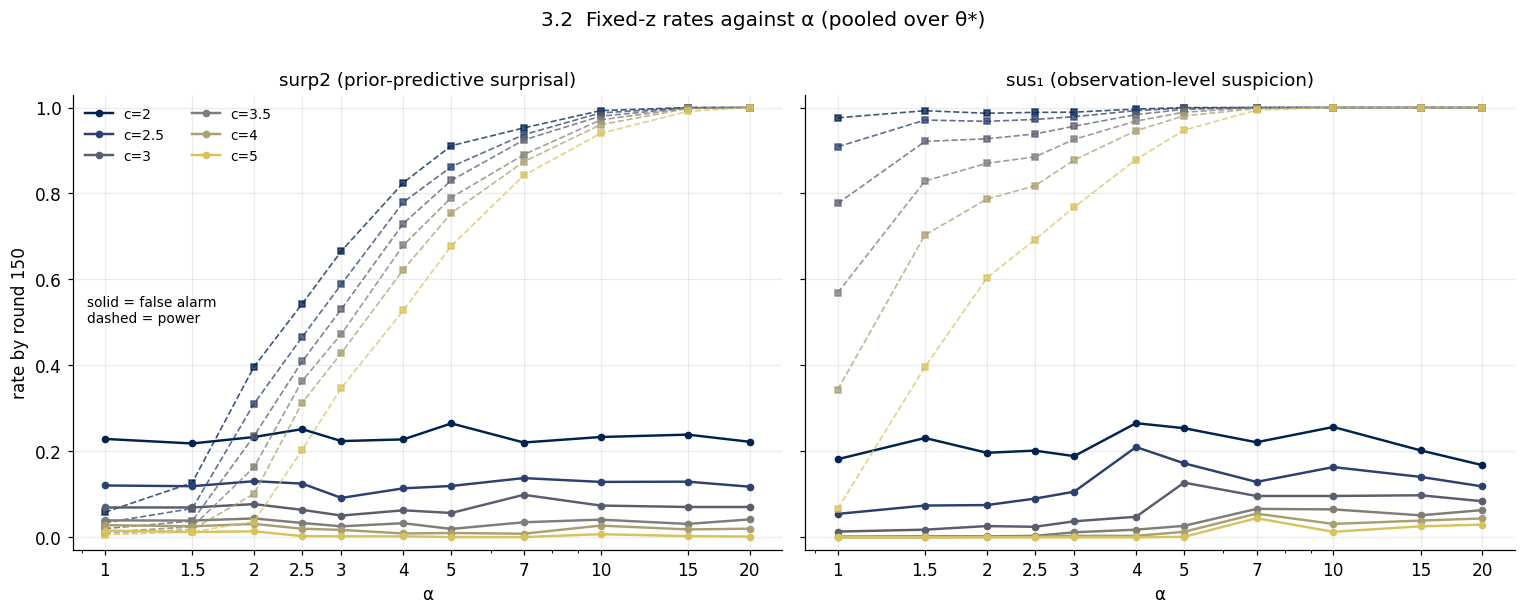

In [14]:
# 3.2 false alarm and power against alpha, lines = c, both scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, sc in zip(axes, SCORES):
    for c in CS:
        fa = rate_by(["alpha"], sc, c, psi_star="inf").sort_values("alpha")
        pw = rate_by(["alpha"], sc, c, psi_star=["high", "low"]).sort_values("alpha")
        ax.plot(fa.alpha, fa.rate, "o-", color=CCOL[c], lw=1.6, ms=4, label=f"c={c:g}")
        ax.plot(pw.alpha, pw.rate, "s--", color=CCOL[c], lw=1.1, ms=3.5, alpha=0.75)
    alpha_axis(ax); ax.set_ylim(-0.03, 1.03); ax.set_title(SCORE_LABEL[sc])
axes[0].set_ylabel("rate by round 150"); axes[0].legend(ncol=2, fontsize=9)
axes[0].text(0.02, 0.5, "solid = false alarm\ndashed = power", transform=axes[0].transAxes, fontsize=9)
fig.suptitle("3.2  Fixed-z rates against α (pooled over θ*)", y=1.01)
save_fig(fig, "S4_rates_vs_alpha"); plt.show()

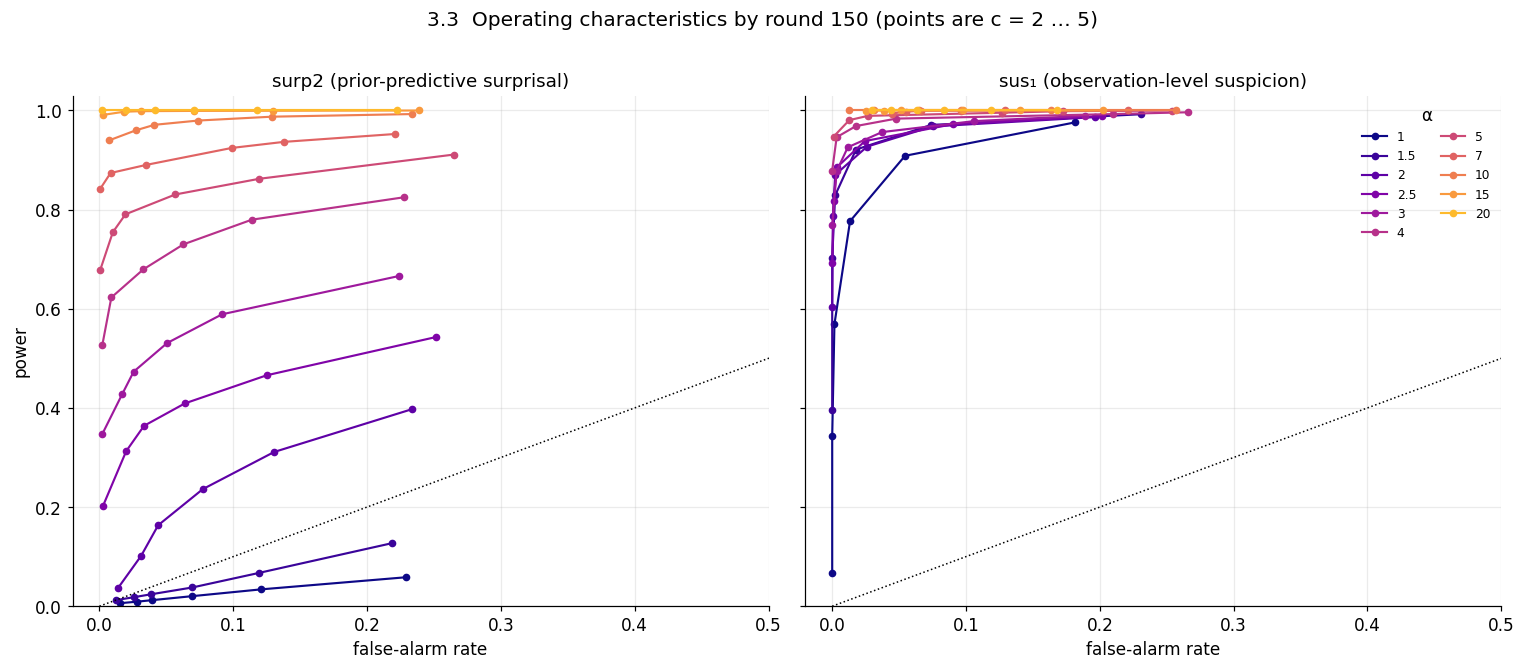

In [15]:
# 3.3 ROC-style: each line is one alpha traced through the c values
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, sc in zip(axes, SCORES):
    for a in ALPHAS:
        pts = [fa_power(sc, c, alpha=a) for c in CS]
        ax.plot([p[0] for p in pts], [p[1] for p in pts], "o-", color=ACOL[a], ms=4, lw=1.4, label=f"{a:g}")
    ax.plot([0, 1], [0, 1], "k:", lw=1); ax.set_xlim(-0.02, 0.5); ax.set_ylim(0, 1.03)
    ax.set_title(SCORE_LABEL[sc]); ax.set_xlabel("false-alarm rate")
axes[0].set_ylabel("power"); axes[1].legend(title="α", ncol=2, fontsize=8)
fig.suptitle("3.3  Operating characteristics by round 150 (points are c = 2 … 5)", y=1.01)
save_fig(fig, "S5_roc"); plt.show()

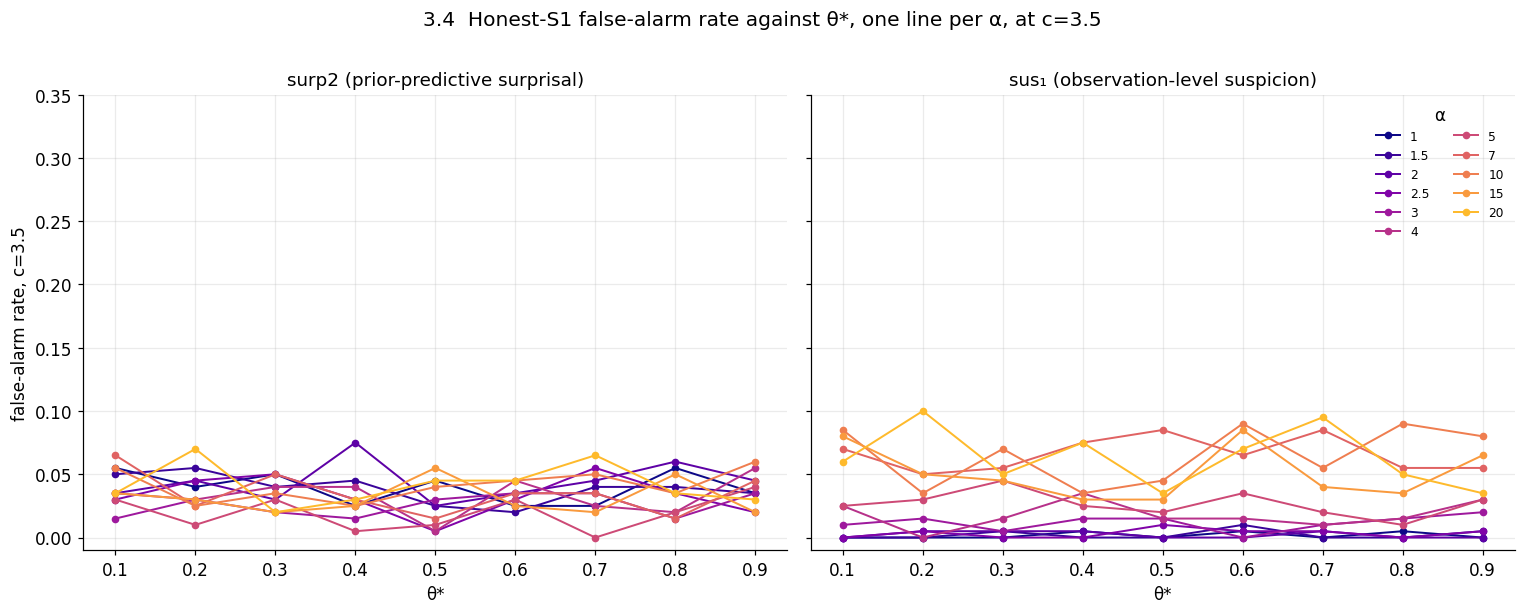

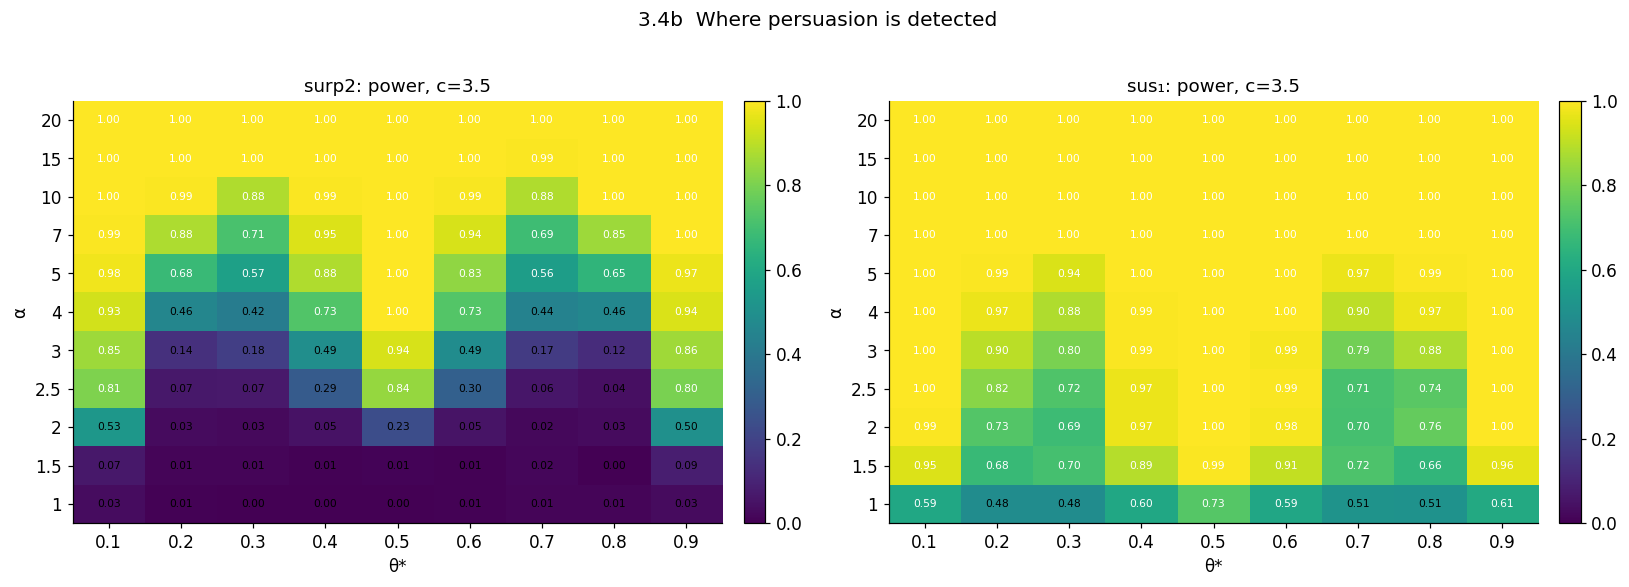

In [16]:
# 3.4 theta* explicitly: false alarm against theta*, lines = alpha, per score
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, sc in zip(axes, SCORES):
    r = rate_by(["theta_star", "alpha"], sc, FOCUS["c"], psi_star="inf")
    for a in ALPHAS:
        q = r[r.alpha == a].sort_values("theta_star")
        ax.plot(q.theta_star, q.rate, "o-", color=ACOL[a], ms=4, lw=1.3, label=f"{a:g}")
    ax.set_title(SCORE_LABEL[sc]); ax.set_xlabel("θ*"); ax.set_ylim(-0.01, 0.35)
axes[0].set_ylabel(f"false-alarm rate, c={FOCUS['c']:g}"); axes[1].legend(title="α", ncol=2, fontsize=8)
fig.suptitle("3.4  Honest-S1 false-alarm rate against θ*, one line per α, at c=3.5", y=1.01)
save_fig(fig, "S6_fa_vs_theta"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for ax, sc in zip(axes, SCORES):
    P = rate_by(["theta_star", "alpha"], sc, FOCUS["c"], psi_star=["high", "low"]).pivot(index="alpha", columns="theta_star", values="rate")
    heat(ax, P.values, P.columns, P.index, "θ*", "α", f"{SCORE_SHORT[sc]}: power, c={FOCUS['c']:g}", vmin=0, vmax=1, fontsize=7)
fig.suptitle("3.4b  Where persuasion is detected", y=1.02)
save_fig(fig, "S7_power_heatmaps"); plt.show()

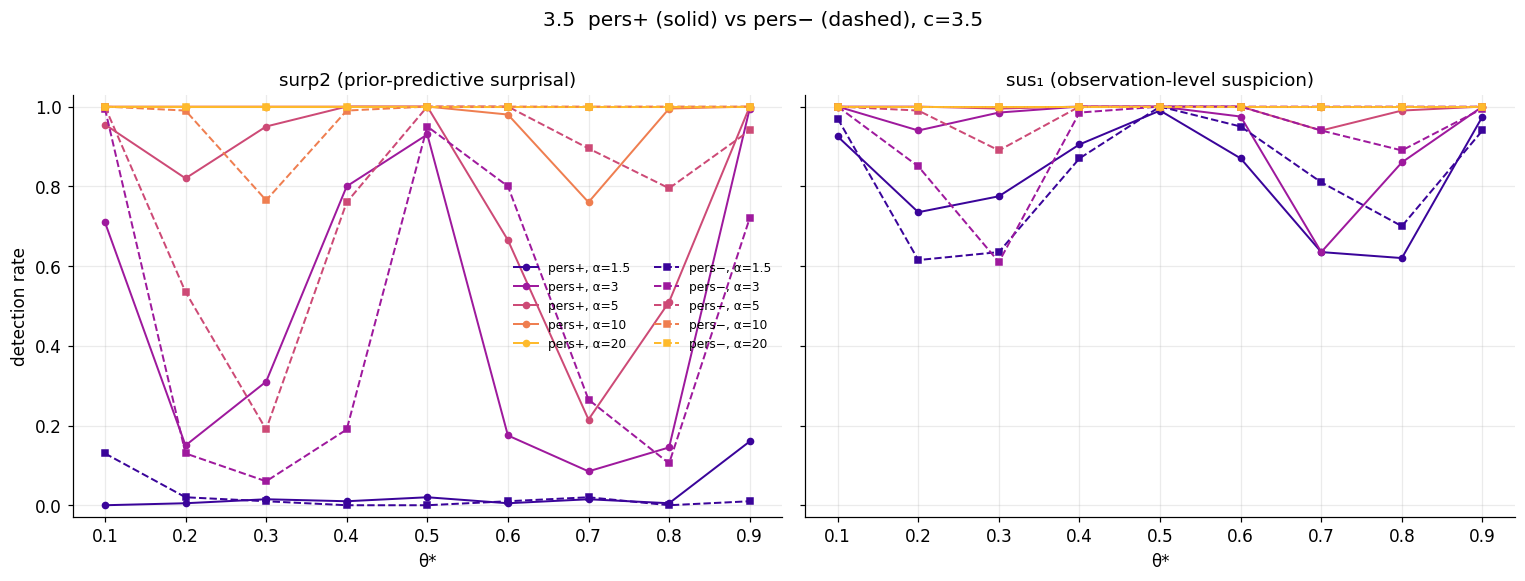

In [17]:
# 3.5 pers+ vs pers- are mirror images in theta*
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for ax, sc in zip(axes, SCORES):
    for psi, mk in [("high", "o-"), ("low", "s--")]:
        r = rate_by(["theta_star", "alpha"], sc, FOCUS["c"], psi_star=psi)
        for a in [1.5, 3.0, 5.0, 10.0, 20.0]:
            q = r[r.alpha == a].sort_values("theta_star")
            ax.plot(q.theta_star, q.rate, mk, color=ACOL[a], ms=4, lw=1.3, label=f"{PSI_LABEL[psi]}, α={a:g}")
    ax.set_title(SCORE_LABEL[sc]); ax.set_xlabel("θ*"); ax.set_ylim(-0.03, 1.03)
axes[0].set_ylabel("detection rate"); axes[0].legend(ncol=2, fontsize=8)
fig.suptitle(f"3.5  pers+ (solid) vs pers− (dashed), c={FOCUS['c']:g}", y=1.01)
save_fig(fig, "S8_pers_asymmetry"); plt.show()

In [18]:
# 3.6 the alpha* table: smallest alpha at which the pooled false-alarm rate is under target
rows = []
for sc in SCORES:
    for c in CS:
        fa = rate_by(["alpha"], sc, c, psi_star="inf").set_index("alpha")["rate"]
        for target in (0.05, 0.10):
            ok = fa[fa < target]
            if ok.empty:
                rows.append(dict(score=SCORE_SHORT[sc], c=c, target=target, alpha_star=np.nan, power=np.nan, median_tau=np.nan)); continue
            a = float(ok.index.min())
            d = sel(RUS, alpha=a, psi_star=["high", "low"])
            t = d[tau_col(sc, c)]; t = t[t > 0]
            rows.append(dict(score=SCORE_SHORT[sc], c=c, target=target, alpha_star=a,
                             power=hit(d, sc, c).mean(), median_tau=float(t.median()) if len(t) else np.nan))
display(pd.DataFrame(rows).round(3).pivot(index=["score", "c"], columns="target", values=["alpha_star", "power", "median_tau"]))

alpha_star       power        median_tau       
target          0.05 0.10   0.05   0.10       0.05   0.10
score c                                                  
surp2 2.0        NaN  NaN    NaN    NaN        NaN    NaN
      2.5        NaN  3.0    NaN  0.589        NaN   20.0
      3.0        NaN  1.0    NaN  0.020        NaN   10.0
      3.5        1.0  1.0  0.012  0.012       10.5   10.5
      4.0        1.0  1.0  0.009  0.009       11.0   11.0
      5.0        1.0  1.0  0.006  0.006       15.5   15.5
sus₁  2.0        NaN  NaN    NaN    NaN        NaN    NaN
      2.5        NaN  1.0    NaN  0.909        NaN   52.0
      3.0        1.0  1.0  0.777  0.777       76.0   76.0
      3.5        1.0  1.0  0.569  0.569       97.0   97.0
      4.0        1.0  1.0  0.344  0.344      110.0  110.0
      5.0        1.0  1.0  0.066  0.066      131.5  131.5

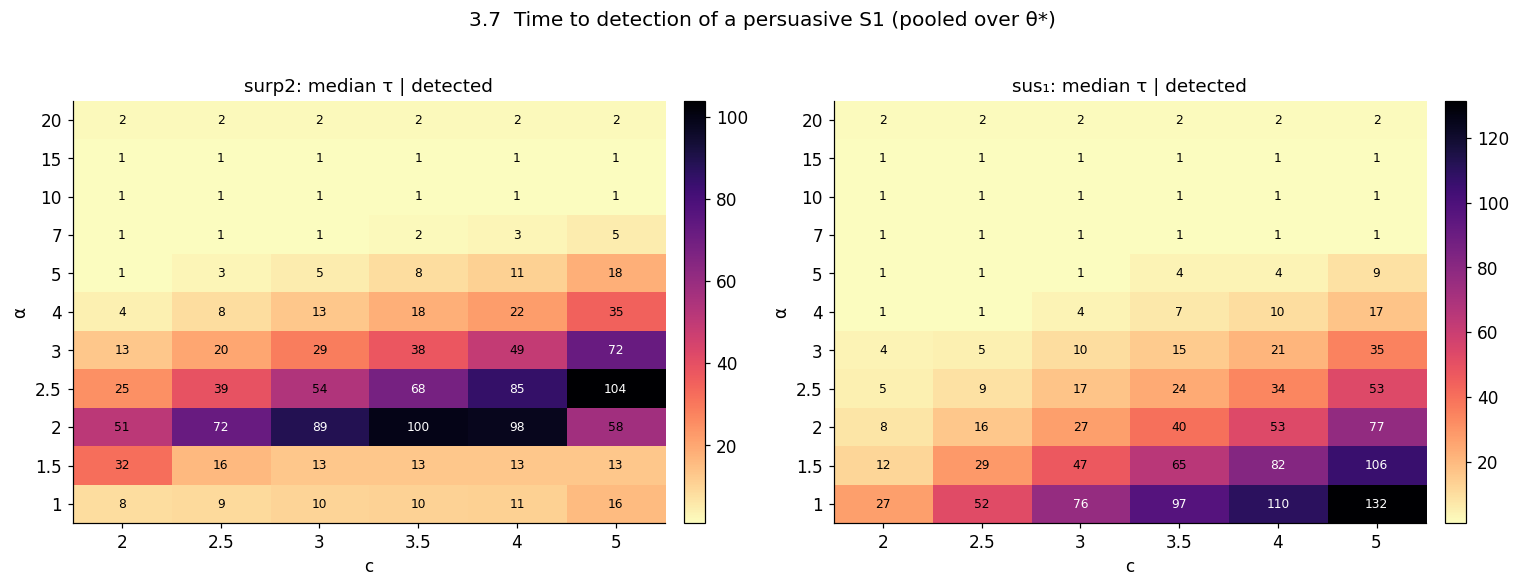

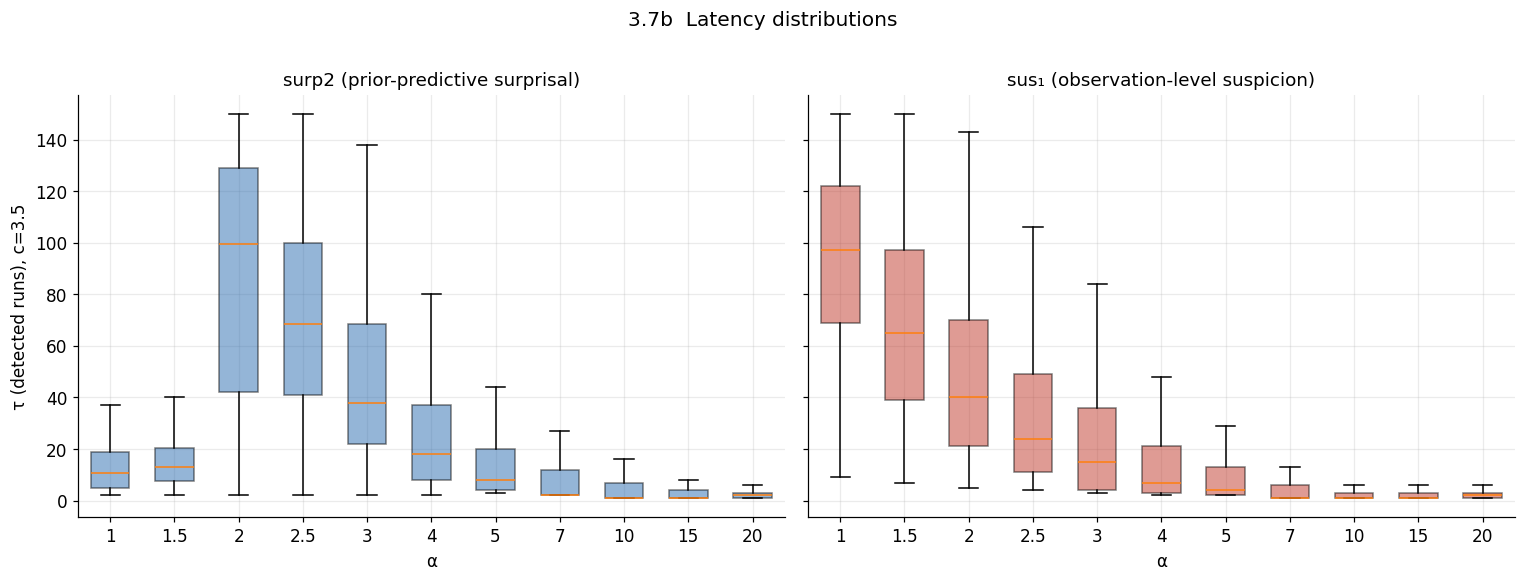

In [19]:
# 3.7 latency: median tau (persuaders) over (alpha, c), and its spread at the focus c
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
for ax, sc in zip(axes, SCORES):
    M = np.full((len(ALPHAS), len(CS)), np.nan)
    for i, a in enumerate(ALPHAS):
        for j, c in enumerate(CS):
            t = sel(RUS, alpha=a, psi_star=["high", "low"])[tau_col(sc, c)]; t = t[t > 0]
            if len(t): M[i, j] = t.median()
    heat(ax, M, CS, ALPHAS, "c", "α", f"{SCORE_SHORT[sc]}: median τ | detected", cmap="magma_r", fmt="{:.0f}", fontsize=8)
fig.suptitle("3.7  Time to detection of a persuasive S1 (pooled over θ*)", y=1.02)
save_fig(fig, "S9_median_tau"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for ax, sc in zip(axes, SCORES):
    data, labels = [], []
    for a in ALPHAS:
        t = sel(RUS, alpha=a, psi_star=["high", "low"])[tau_col(sc, FOCUS["c"])]; t = t[t > 0]
        data.append(t.to_numpy()); labels.append(f"{a:g}")
    bp = ax.boxplot(data, labels=labels, showfliers=False, patch_artist=True, widths=0.6)
    for p in bp["boxes"]:
        p.set_facecolor(COL[sc]); p.set_alpha(0.5)
    ax.set_title(SCORE_LABEL[sc]); ax.set_xlabel("α")
axes[0].set_ylabel(f"τ (detected runs), c={FOCUS['c']:g}")
fig.suptitle("3.7b  Latency distributions", y=1.01)
save_fig(fig, "S9b_latency_box"); plt.show()

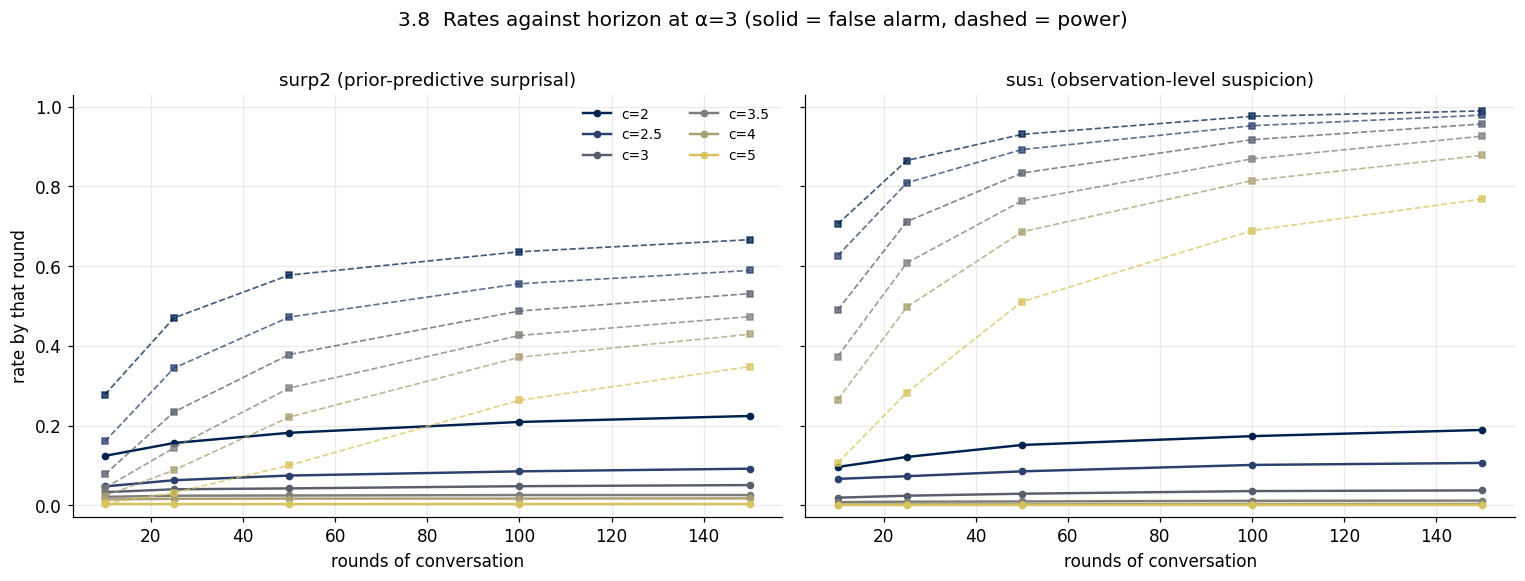

In [20]:
# 3.8 horizon: rates by round t, and survival of the honest speaker
H = [10, 25, 50, 100, 150]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for ax, sc in zip(axes, SCORES):
    for c in CS:
        fa = [fa_power(sc, c, horizon=h, alpha=FOCUS["alpha"])[0] for h in H]
        pw = [fa_power(sc, c, horizon=h, alpha=FOCUS["alpha"])[1] for h in H]
        ax.plot(H, fa, "o-", color=CCOL[c], lw=1.6, ms=4, label=f"c={c:g}")
        ax.plot(H, pw, "s--", color=CCOL[c], lw=1.1, ms=3.5, alpha=0.75)
    ax.set_title(SCORE_LABEL[sc]); ax.set_xlabel("rounds of conversation"); ax.set_ylim(-0.03, 1.03)
axes[0].set_ylabel("rate by that round"); axes[0].legend(ncol=2, fontsize=9)
fig.suptitle(f"3.8  Rates against horizon at α={FOCUS['alpha']:g} (solid = false alarm, dashed = power)", y=1.01)
save_fig(fig, "S10_horizon"); plt.show()

## 4. Stopping rules

Every rule is a boundary B(t, V<sub>t</sub>) compared against S<sub>t</sub> = t·Sus(t),
scored offline on the dense panels. Following the earlier analysis, α = 1 is
excluded here (at α = 1 the speaker is almost literal and there is nothing to
detect); set `EXCLUDE_ALPHA_1 = False` to include it.

| rule | boundary | idea |
|---|---|---|
| `fixed_z(c)` | c√V<sub>t</sub> | the production rule |
| `warmup(c, t₀)` | c√V<sub>t</sub> for t ≥ t₀, else ∞ | skip the rounds where the CLT has not arrived |
| `lil(c)` | c√(2 V<sub>t</sub> log log t) | law of the iterated logarithm |
| `robbins(δ, ρ)` | √((V<sub>t</sub>+ρ) log((V<sub>t</sub>+ρ)/(ρδ²))) | anytime-valid normal mixture, P(ever cross) ≤ δ |
| `empirical(δ)` | c<sub>δ</sub>√V<sub>t</sub>, c<sub>δ</sub> from null quantiles on a train split | horizon-committed calibration, scored held-out |

In [21]:
EXCLUDE_ALPHA_1 = True
meta = RUS[["theta_star", "psi_star", "alpha", "sim"]].reset_index(drop=True)
USE = (meta.alpha != 1.0).to_numpy() if EXCLUDE_ALPHA_1 else np.ones(len(meta), bool)
IS_NULL, IS_PP, IS_PM = (meta.psi_star == "inf").to_numpy(), (meta.psi_star == "high").to_numpy(), (meta.psi_star == "low").to_numpy()
NULL, ALT = USE & IS_NULL, USE & (IS_PP | IS_PM)
ALPHAS_R = [a for a in ALPHAS if not (EXCLUDE_ALPHA_1 and a == 1.0)]
S = {sc: PANEL[f"S_{sc}"] for sc in SCORES}
V = {sc: PANEL[f"V_{sc}"] for sc in SCORES}
RT = ROUNDS.astype(float)

def crossings(sc, boundary, rows):
    s, v = S[sc][rows], V[sc][rows]
    crossed = s > boundary(RT, v)
    fired = crossed.any(axis=1)
    return fired, np.where(fired, crossed.argmax(axis=1) + 1, 0)

def fixed_z(c):      return lambda t, v: c * np.sqrt(np.maximum(v, 0.0))
def warmup(c, t0):   return lambda t, v: np.where(t >= t0, c * np.sqrt(np.maximum(v, 0.0)), np.inf)
def lil(c):          return lambda t, v: c * np.sqrt(2.0 * np.maximum(v, 0.0) * np.log(np.log(np.maximum(t, 3.0))))
def robbins(delta, rho):
    def b(t, v):
        w = np.maximum(v, 0.0) + rho
        return np.sqrt(w * np.log(np.maximum(w / (rho * delta ** 2), 1.0 + 1e-12)))
    return b
def empirical_c(sc, delta, rows):
    z = np.where(V[sc][rows] > 0, S[sc][rows] / np.sqrt(np.maximum(V[sc][rows], 1e-300)), -np.inf)
    return float(np.quantile(z.max(axis=1), 1.0 - delta))

RHO = {sc: float(np.median(V[sc][NULL][:, -1])) for sc in SCORES}
TRAIN = NULL & (meta.sim.to_numpy() % 2 == 0)
TEST_NULL = NULL & (meta.sim.to_numpy() % 2 == 1)

def evaluate(sc, boundary, null_rows=None):
    null_rows = NULL if null_rows is None else null_rows
    f_n, _ = crossings(sc, boundary, null_rows)
    f_p, t_p = crossings(sc, boundary, USE & IS_PP)
    f_m, t_m = crossings(sc, boundary, USE & IS_PM)
    fpr_t = np.maximum.accumulate(S[sc][null_rows] > boundary(RT, V[sc][null_rows]), axis=1).mean(axis=0)
    tau = np.concatenate([t_p[f_p], t_m[f_m]])
    return dict(FPR=float(f_n.mean()), power_plus=float(f_p.mean()), power_minus=float(f_m.mean()),
                power=float(0.5 * (f_p.mean() + f_m.mean())), median_tau=float(np.median(tau)) if tau.size else np.nan, fpr_t=fpr_t)

DELTA = 0.05
RULES = {}
for sc in SCORES:
    ce = empirical_c(sc, DELTA, TRAIN)
    RULES[sc] = {"fixed_z c=2": (fixed_z(2.0), NULL), "fixed_z c=3.5": (fixed_z(3.5), NULL),
                 "warmup c=3.5, t≥10": (warmup(3.5, 10), NULL), "LIL c=2": (lil(2.0), NULL),
                 f"Robbins δ={DELTA}": (robbins(DELTA, RHO[sc]), NULL),
                 f"empirical δ={DELTA} (c={ce:.2f}, held-out)": (fixed_z(ce), TEST_NULL)}
rows = []
for sc in SCORES:
    for name, (b, nr) in RULES[sc].items():
        r = evaluate(sc, b, nr); r.pop("fpr_t")
        rows.append(dict(score=SCORE_SHORT[sc], rule=name, **r))
R1 = pd.DataFrame(rows)
print(f"nominal-level comparison (train/held-out split: {TRAIN.sum():,} / {TEST_NULL.sum():,} null runs; rho = {RHO})")
display(R1.round(3))

# self-check against the stored R1 (same rules, same data)
old = pd.read_csv(os.path.join(SWEEP_DIR, "analyses", "stopping_rules", "R1_rule_comparison.csv"))
for lab, key in [("fixed_z c=2", "fixed_z c=2"), ("fixed_z c=3.5", "fixed_z c=3.5"), ("LIL c=2", "LIL c=2")]:
    for sc, old_sc in [("surp2", "surp2"), ("sus1", "sus_1")]:
        a = R1[(R1.score == SCORE_SHORT[sc]) & (R1.rule == key)].iloc[0]; o = old[(old.score == old_sc) & (old.rule == lab)].iloc[0]
        assert abs(a.FPR - o.FPR) < 5e-4 and abs(a.power - o.TPR_avg) < 5e-4, (sc, lab)
print("self-check PASSED: reproduces R1_rule_comparison.csv")

nominal-level comparison (train/held-out split: 9,000 / 9,000 null runs; rho = {'surp2': 63.72274639951765, 'sus1': 35.107239445679475})


,score,rule,FPR,power_plus,power_minus,power,median_tau
0,surp2,fixed_z c=2,0.234,0.743,0.740,0.741,3.0
1,surp2,fixed_z c=3.5,0.034,0.635,0.636,0.635,5.0
2,surp2,"warmup c=3.5, t≥10",0.015,0.628,0.630,0.629,10.0
3,surp2,LIL c=2,0.331,0.727,0.729,0.728,1.0
4,surp2,Robbins δ=0.05,0.002,0.589,0.592,0.591,17.0
5,surp2,"empirical δ=0.05 (c=3.34, held-out)",0.042,0.646,0.647,0.646,4.0
6,sus₁,fixed_z c=2,0.219,0.996,0.995,0.995,2.0
7,sus₁,fixed_z c=3.5,0.031,0.947,0.947,0.947,5.0
8,sus₁,"warmup c=3.5, t≥10",0.016,0.946,0.946,0.946,10.0
9,sus₁,LIL c=2,0.268,0.974,0.972,0.973,1.0


self-check PASSED: reproduces R1_rule_comparison.csv


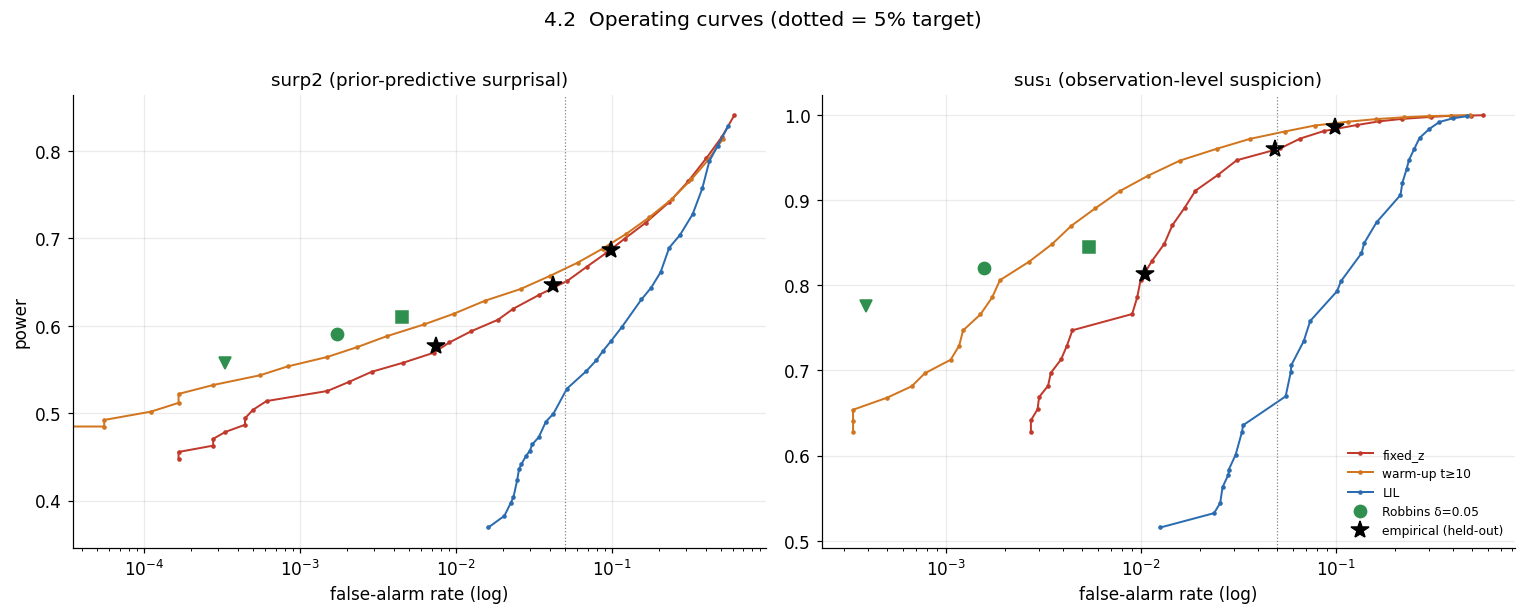

In [22]:
# 4.2 operating curves: sweep each rule's parameter
GRID = np.linspace(1.0, 8.0, 29)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, sc in zip(axes, SCORES):
    for label, mk, col in [("fixed_z", fixed_z, "#c0392b"), ("warm-up t≥10", lambda c: warmup(c, 10), "#d1751f"), ("LIL", lil, "#2b6cb0")]:
        pts = [evaluate(sc, mk(c)) for c in GRID]
        ax.plot([p["FPR"] for p in pts], [p["power"] for p in pts], ".-", color=col, ms=4, lw=1.3, label=label)
    for d, m in [(0.01, "v"), (0.05, "o"), (0.10, "s")]:
        r = evaluate(sc, robbins(d, RHO[sc]))
        ax.plot(r["FPR"], r["power"], m, ms=8, color="#2f8f4e", label=f"Robbins δ={d}" if d == 0.05 else None)
    for d in (0.01, 0.05, 0.10):
        r = evaluate(sc, fixed_z(empirical_c(sc, d, TRAIN)), null_rows=TEST_NULL)
        ax.plot(r["FPR"], r["power"], "*", ms=12, color="k", label="empirical (held-out)" if d == 0.05 else None)
    ax.axvline(0.05, color="grey", lw=0.8, ls=":"); ax.set_xscale("log")
    ax.set_title(SCORE_LABEL[sc]); ax.set_xlabel("false-alarm rate (log)")
axes[0].set_ylabel("power"); axes[1].legend(fontsize=8, loc="lower right")
fig.suptitle("4.2  Operating curves (dotted = 5% target)", y=1.01)
save_fig(fig, "R2_operating_curves"); plt.show()

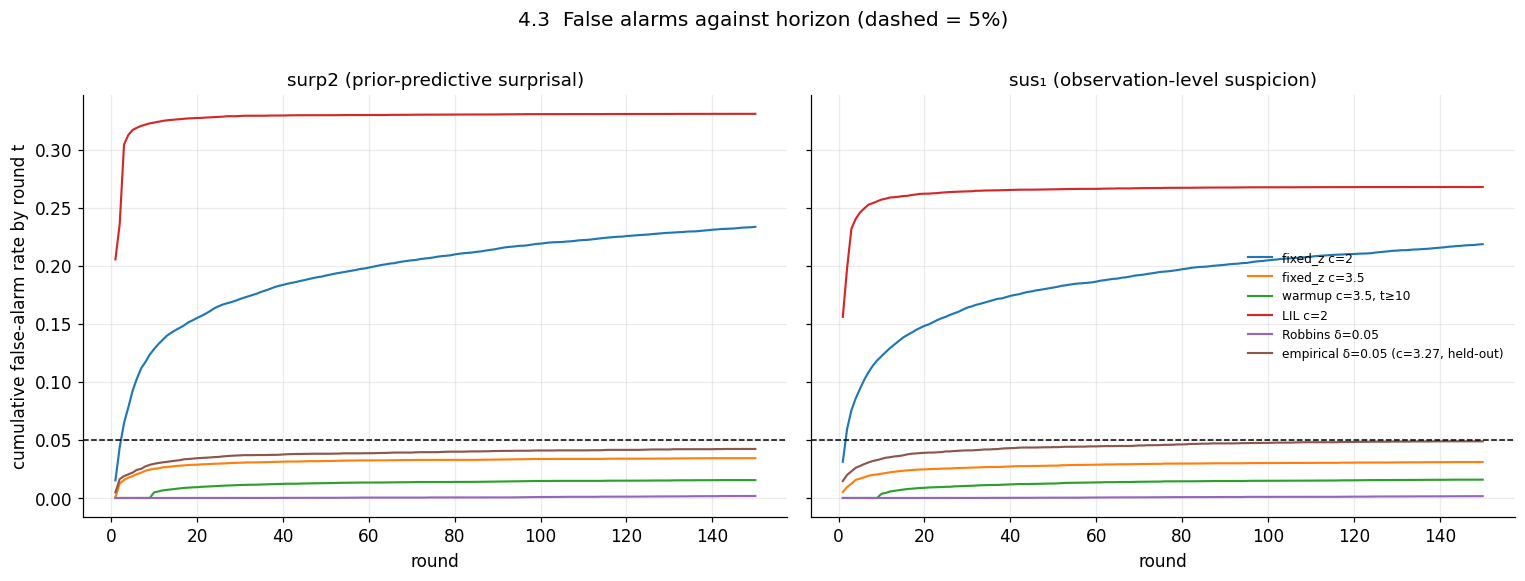

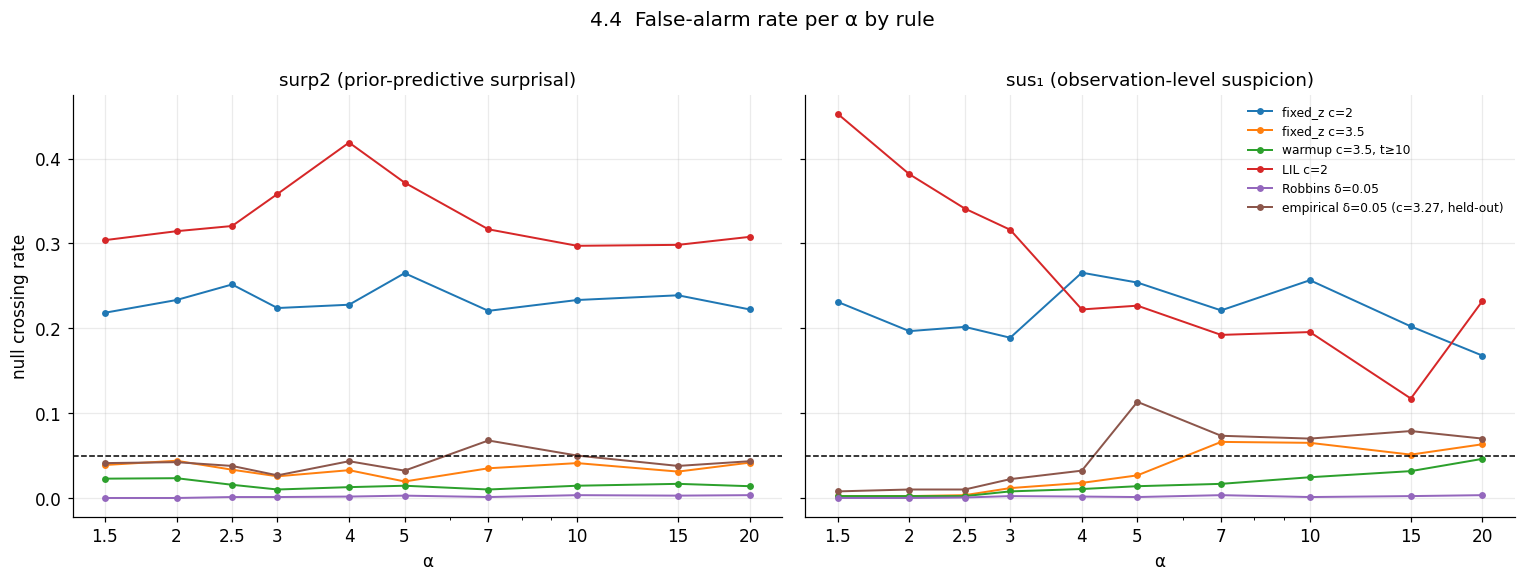

spread of the false-alarm rate across alpha (max - min):


surp2  Robbins δ=0.05                         0.003
sus₁   Robbins δ=0.05                         0.003
surp2  warmup c=3.5, t≥10                     0.013
       fixed_z c=3.5                          0.024
       empirical δ=0.05 (c=3.34, held-out)    0.041
sus₁   warmup c=3.5, t≥10                     0.044
surp2  fixed_z c=2                            0.047
sus₁   fixed_z c=3.5                          0.064
       fixed_z c=2                            0.098
       empirical δ=0.05 (c=3.27, held-out)    0.106
surp2  LIL c=2                                0.122
sus₁   LIL c=2                                0.336
dtype: float64

In [23]:
# 4.3 how false alarms accumulate with the horizon, and 4.4 how uniform they are in alpha
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for ax, sc in zip(axes, SCORES):
    for name, (b, nr) in RULES[sc].items():
        ax.plot(ROUNDS, evaluate(sc, b, nr)["fpr_t"], lw=1.4, label=name)
    ax.axhline(DELTA, color="k", ls="--", lw=1); ax.set_title(SCORE_LABEL[sc]); ax.set_xlabel("round")
axes[0].set_ylabel("cumulative false-alarm rate by round t"); axes[1].legend(fontsize=8)
fig.suptitle("4.3  False alarms against horizon (dashed = 5%)", y=1.01)
save_fig(fig, "R3_fpr_vs_horizon"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
spread = {}
for ax, sc in zip(axes, SCORES):
    for name, (b, nr) in RULES[sc].items():
        ys = [crossings(sc, b, nr & (meta.alpha == a).to_numpy())[0].mean() for a in ALPHAS_R]
        spread[(SCORE_SHORT[sc], name)] = max(ys) - min(ys)
        ax.plot(ALPHAS_R, ys, "o-", ms=3.5, lw=1.3, label=name)
    ax.axhline(DELTA, color="k", ls="--", lw=1); alpha_axis(ax, ALPHAS_R); ax.set_title(SCORE_LABEL[sc])
axes[0].set_ylabel("null crossing rate"); axes[1].legend(fontsize=8)
fig.suptitle("4.4  False-alarm rate per α by rule", y=1.01)
save_fig(fig, "R4_fpr_per_alpha"); plt.show()
print("spread of the false-alarm rate across alpha (max - min):")
display(pd.Series(spread).round(3).sort_values())

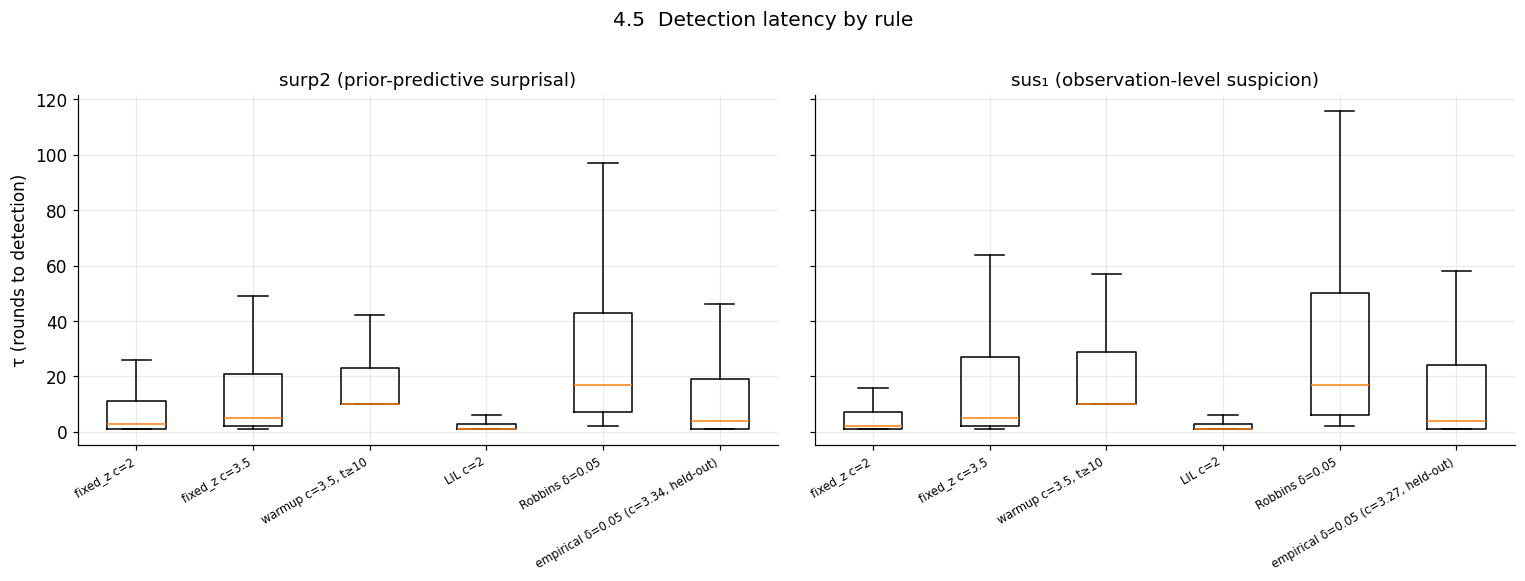

In [24]:
# 4.5 latency by rule (detected persuasive runs only)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for ax, sc in zip(axes, SCORES):
    data, labels = [], []
    for name, (b, _) in RULES[sc].items():
        f_p, t_p = crossings(sc, b, USE & IS_PP); f_m, t_m = crossings(sc, b, USE & IS_PM)
        t = np.concatenate([t_p[f_p], t_m[f_m]])
        if t.size:
            data.append(t); labels.append(name)
    ax.boxplot(data, labels=labels, showfliers=False)
    ax.set_title(SCORE_LABEL[sc]); ax.tick_params(axis="x", rotation=30, labelsize=7.5)
    for lab in ax.get_xticklabels(): lab.set_ha("right")
axes[0].set_ylabel("τ (rounds to detection)")
fig.suptitle("4.5  Detection latency by rule", y=1.01)
save_fig(fig, "R5_latency"); plt.show()

,score,rule,param,FPR_heldout,power,median_tau,alpha_spread,controls_FPR
0,surp2,fixed_z,3.341,0.042,0.646,4.0,0.041,True
1,surp2,warm-up t≥10,2.868,0.051,0.665,10.0,0.026,True
2,surp2,LIL,4.912,0.046,0.516,2.0,0.047,True
3,surp2,Robbins,0.409,0.053,0.669,10.0,0.058,True
4,sus₁,fixed_z,3.275,0.049,0.959,4.0,0.106,True
5,sus₁,warm-up t≥10,2.790,0.052,0.979,10.0,0.058,True
6,sus₁,LIL,5.916,0.046,0.647,1.0,0.148,True
7,sus₁,Robbins,0.421,0.051,0.930,11.0,0.056,True


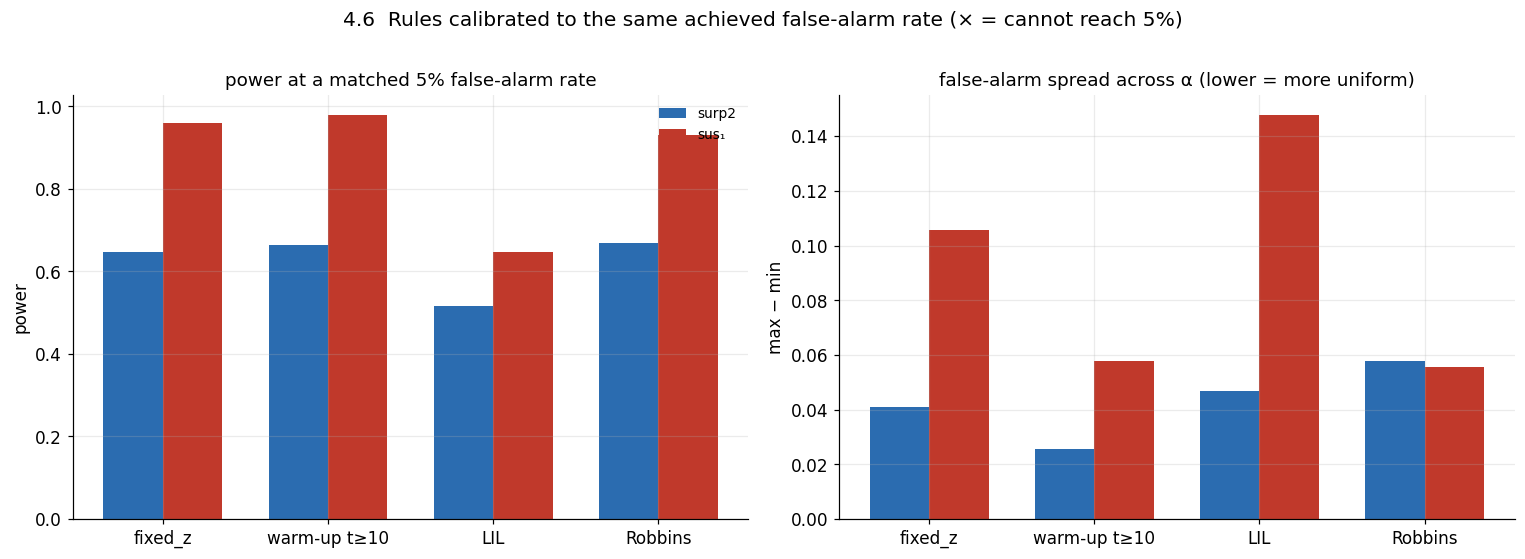

In [25]:
# 4.6 the fair comparison: every rule calibrated to the same *achieved* 5% false-alarm
# rate on the train nulls, scored on the held-out nulls
def calibrate(sc, mk, lo, hi, target=0.05, rises=True, iters=48):
    lo0, hi0 = lo, hi
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        f = evaluate(sc, mk(mid), null_rows=TRAIN)["FPR"]
        if (f < target) == rises: lo = mid
        else: hi = mid
    par = 0.5 * (lo + hi)
    return par, (par >= hi0 * (1 - 1e-6)) or (par <= lo0 * (1 + 1e-6))

rows = []
for sc in SCORES:
    for name, mk, lo, hi, rises in [("fixed_z", fixed_z, 1.0, 200.0, False), ("warm-up t≥10", lambda c: warmup(c, 10), 1.0, 200.0, False),
                                    ("LIL", lil, 0.5, 200.0, False), ("Robbins", lambda d, _s=sc: robbins(d, RHO[_s]), 1e-4, 500.0, True)]:
        par, sat = calibrate(sc, mk, lo, hi, DELTA, rises)
        r = evaluate(sc, mk(par), null_rows=TEST_NULL)
        per_a = [crossings(sc, mk(par), TEST_NULL & (meta.alpha == a).to_numpy())[0].mean() for a in ALPHAS_R]
        rows.append(dict(score=SCORE_SHORT[sc], rule=name, param=round(par, 3), FPR_heldout=r["FPR"], power=r["power"],
                         median_tau=r["median_tau"], alpha_spread=max(per_a) - min(per_a), controls_FPR=bool(r["FPR"] <= DELTA * 1.15 and not sat)))
R2 = pd.DataFrame(rows)
display(R2.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = R2[R2.score == SCORE_SHORT["surp2"]].rule.tolist(); w = 0.36
for k, sc in enumerate(SCORES):
    sub = R2[R2.score == SCORE_SHORT[sc]].reset_index(drop=True); x = np.arange(len(sub))
    axes[0].bar(x + (k - 0.5) * w, sub.power, w, color=COL[sc], label=SCORE_SHORT[sc])
    axes[1].bar(x + (k - 0.5) * w, sub.alpha_spread, w, color=COL[sc], label=SCORE_SHORT[sc])
    for ax, colname in [(axes[0], "power"), (axes[1], "alpha_spread")]:
        for i in range(len(sub)):
            if not sub.loc[i, "controls_FPR"]:
                ax.text(i + (k - 0.5) * w, sub.loc[i, colname], "×", ha="center", va="bottom", fontsize=12, color="crimson", weight="bold")
for ax, ttl, yl in [(axes[0], "power at a matched 5% false-alarm rate", "power"), (axes[1], "false-alarm spread across α (lower = more uniform)", "max − min")]:
    ax.set_xticks(range(len(labels)), labels); ax.set_title(ttl); ax.set_ylabel(yl)
axes[0].legend(fontsize=9)
fig.suptitle("4.6  Rules calibrated to the same achieved false-alarm rate (× = cannot reach 5%)", y=1.01)
save_fig(fig, "R6_matched_fpr"); plt.show()

## 5. What the credulous listener believes

The sweep stores the whole posterior, so beyond E[θ] it gives the posterior
sd, the entropy, the mass on the true grid point, and whether θ\* sits inside
the listener's own ±2 sd interval. It also stores the literal listener L0, so
the value of one level of pragmatics is measurable.

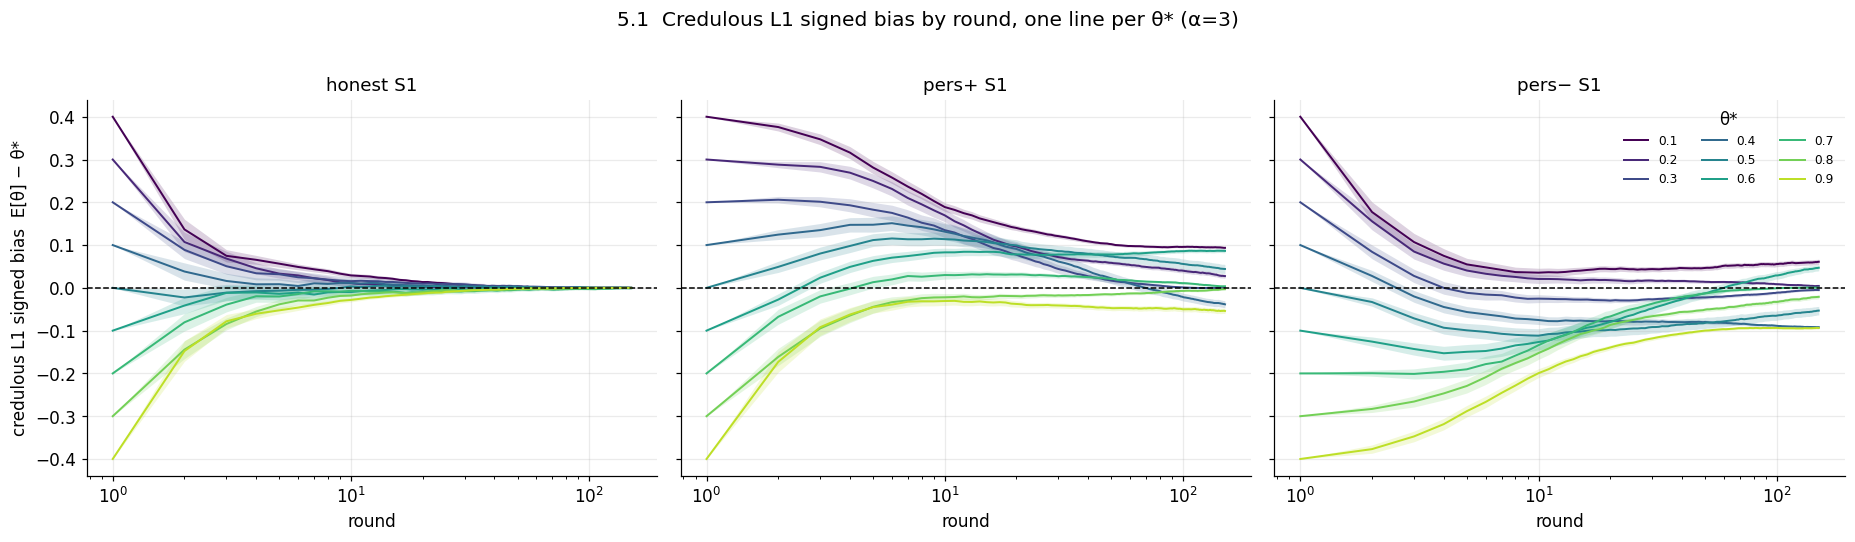

In [26]:
# 5.1 signed bias of the credulous L1 by round, one line per theta*, per speaker type
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, psi in zip(axes, PSIS):
    for th in THETAS:
        q = sel(RS, psi_star=psi, theta_star=th, alpha=FOCUS["alpha"]).sort_values("round")
        band(ax, q["round"], q.L1_bias, q.L1_bias_sd, q.n, TCOL[th], label=f"{th:g}", lw=1.3)
    ax.axhline(0, color="k", lw=1, ls="--"); ax.set_xscale("log")
    ax.set_title(f"{PSI_LABEL[psi]} S1"); ax.set_xlabel("round")
axes[0].set_ylabel("credulous L1 signed bias  E[θ] − θ*"); axes[2].legend(title="θ*", ncol=3, fontsize=8)
fig.suptitle(f"5.1  Credulous L1 signed bias by round, one line per θ* (α={FOCUS['alpha']:g})", y=1.02)
save_fig(fig, "B1_bias_traj"); plt.show()

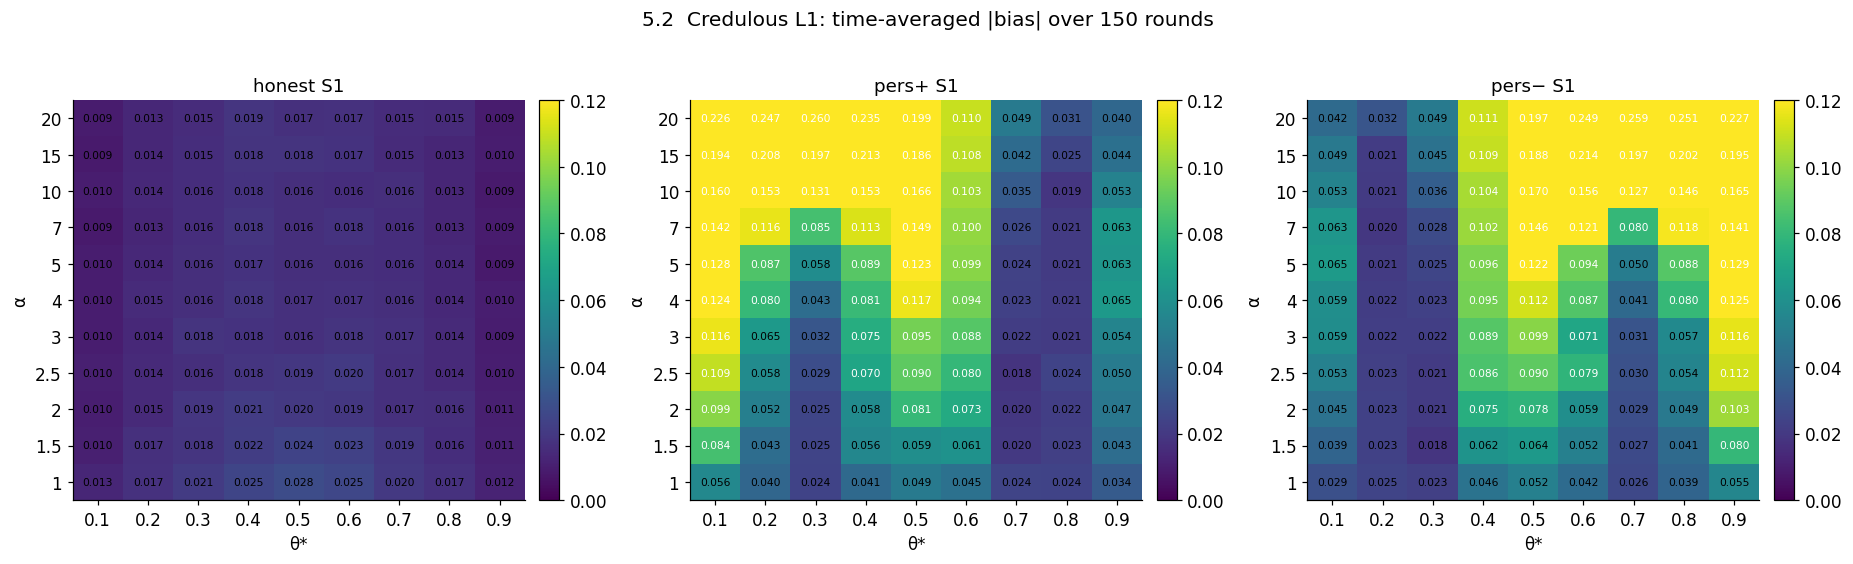

In [27]:
# 5.2 time-averaged |bias| over the grid, per speaker type
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, psi in zip(axes, PSIS):
    M = sel(RS, psi_star=psi).groupby(["alpha", "theta_star"])["L1_abias"].mean().unstack()
    heat(ax, M.values, M.columns, M.index, "θ*", "α", f"{PSI_LABEL[psi]} S1", vmin=0, vmax=0.12, fmt="{:.3f}", fontsize=7)
fig.suptitle("5.2  Credulous L1: time-averaged |bias| over 150 rounds", y=1.02)
save_fig(fig, "B2_abias_heat"); plt.show()

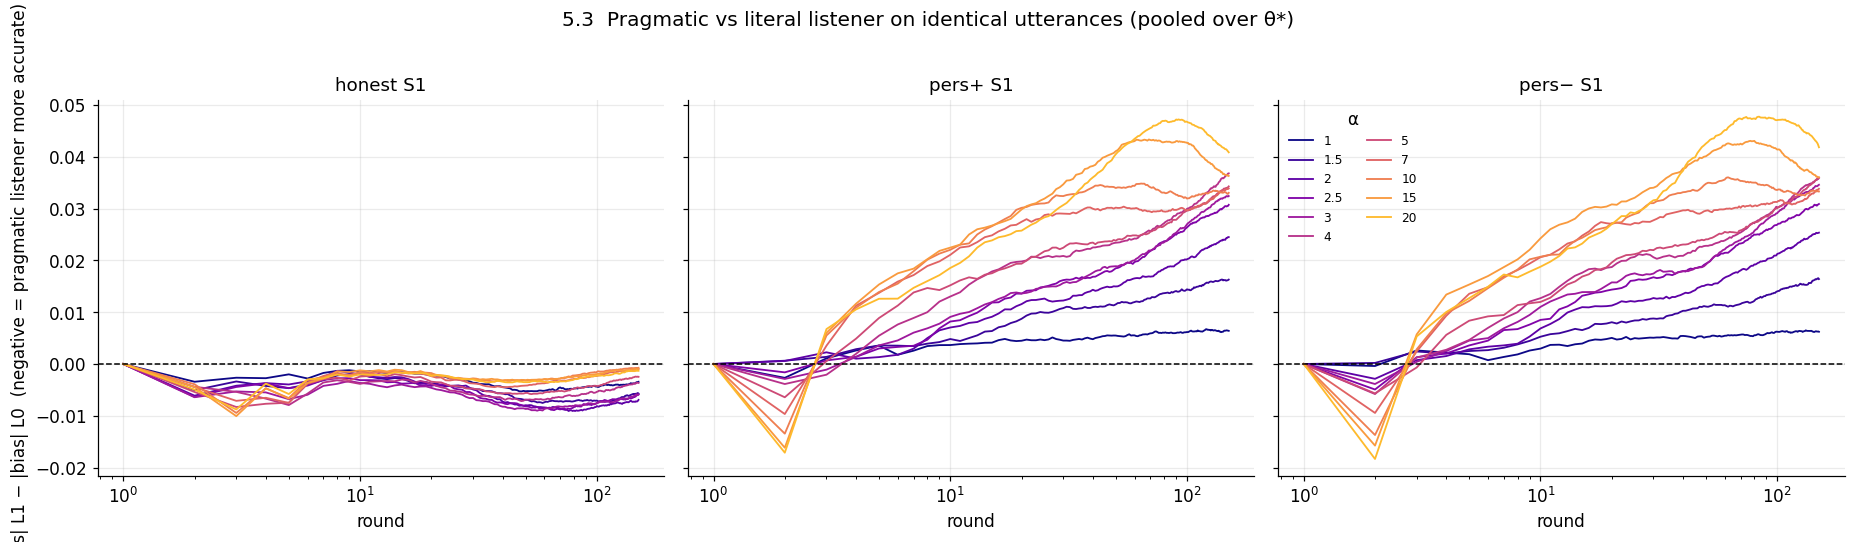

In [28]:
# 5.3 what one level of pragmatics buys: |bias| of L1 minus |bias| of L0, same stream
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, psi in zip(axes, PSIS):
    for a in ALPHAS:
        q = sel(RS, psi_star=psi, alpha=a).groupby("round")[["L1_abias", "L0_abias"]].mean()
        ax.plot(q.index, q.L1_abias - q.L0_abias, color=ACOL[a], lw=1.2, label=f"{a:g}")
    ax.axhline(0, color="k", lw=1, ls="--"); ax.set_xscale("log")
    ax.set_title(f"{PSI_LABEL[psi]} S1"); ax.set_xlabel("round")
axes[0].set_ylabel("|bias| L1 − |bias| L0  (negative = pragmatic listener more accurate)"); axes[2].legend(title="α", ncol=2, fontsize=8)
fig.suptitle("5.3  Pragmatic vs literal listener on identical utterances (pooled over θ*)", y=1.02)
save_fig(fig, "B3_L1_vs_L0"); plt.show()

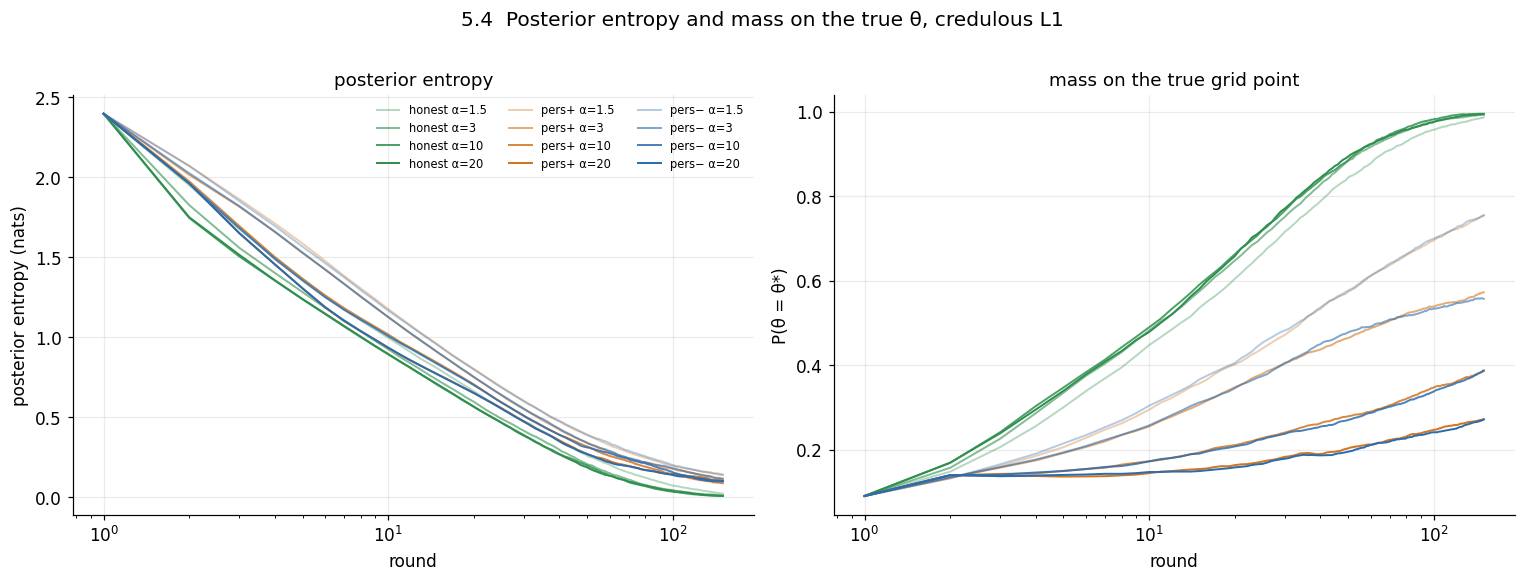

In [29]:
# 5.4 uncertainty: posterior entropy and the mass on the true theta
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
for psi in PSIS:
    for a in [1.5, 3.0, 10.0, 20.0]:
        q = sel(RS, psi_star=psi, alpha=a).groupby("round")[["L1_entropy", "L1_p_true"]].mean()
        axes[0].plot(q.index, q.L1_entropy, color=PSI_COL[psi], lw=1.3, alpha={1.5: 0.35, 3.0: 0.6, 10.0: 0.85, 20.0: 1.0}[a],
                     label=f"{PSI_LABEL[psi]} α={a:g}")
        axes[1].plot(q.index, q.L1_p_true, color=PSI_COL[psi], lw=1.3, alpha={1.5: 0.35, 3.0: 0.6, 10.0: 0.85, 20.0: 1.0}[a])
for ax in axes: ax.set_xscale("log"); ax.set_xlabel("round")
axes[0].set_ylabel("posterior entropy (nats)"); axes[0].set_title("posterior entropy")
axes[1].set_ylabel("P(θ = θ*)"); axes[1].set_title("mass on the true grid point")
axes[0].legend(fontsize=7.5, ncol=3)
fig.suptitle("5.4  Posterior entropy and mass on the true θ, credulous L1", y=1.01)
save_fig(fig, "B4_entropy"); plt.show()

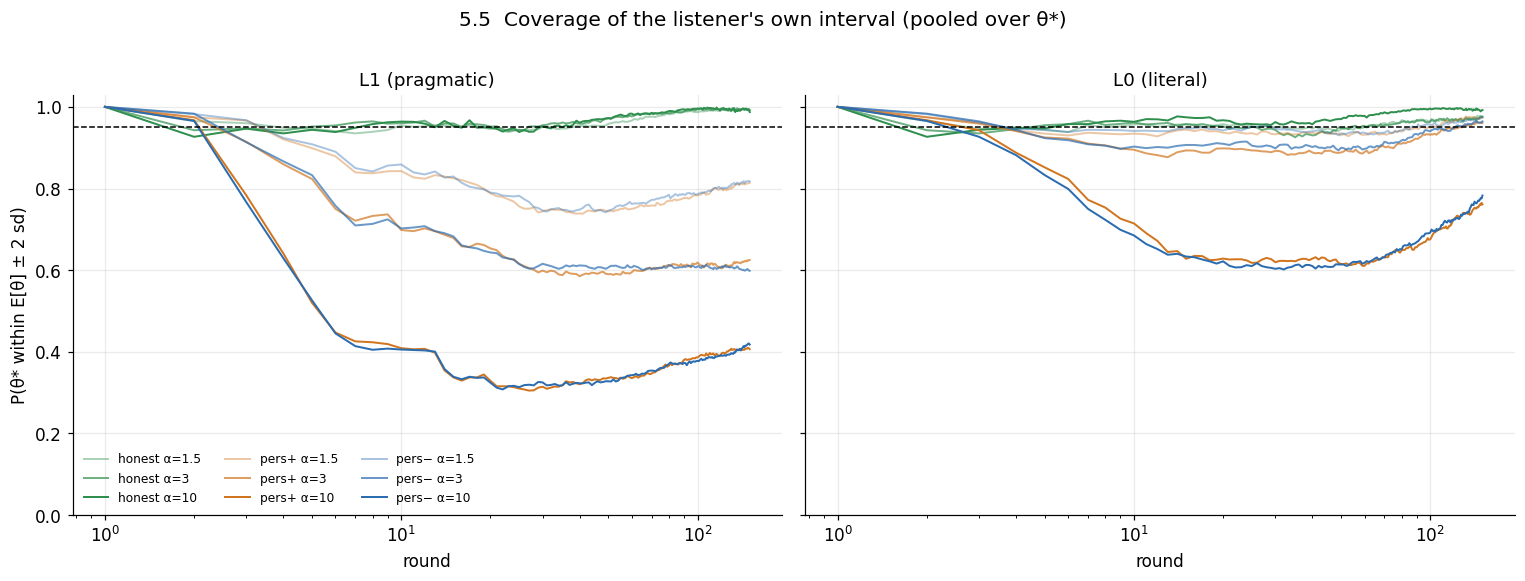

In [30]:
# 5.5 calibration: is theta* inside the listener's own +/-2 sd interval?
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for ax, L in zip(axes, ["L1", "L0"]):
    for psi in PSIS:
        for a in [1.5, 3.0, 10.0]:
            q = sel(RS, psi_star=psi, alpha=a).groupby("round")[f"{L}_cov"].mean()
            ax.plot(q.index, q.values, color=PSI_COL[psi], lw=1.3, alpha={1.5: 0.4, 3.0: 0.7, 10.0: 1.0}[a],
                    label=f"{PSI_LABEL[psi]} α={a:g}" if ax is axes[0] else None)
    ax.axhline(0.95, color="k", lw=1, ls="--"); ax.set_xscale("log"); ax.set_ylim(0, 1.03)
    ax.set_title(f"{L} ({'pragmatic' if L == 'L1' else 'literal'})"); ax.set_xlabel("round")
axes[0].set_ylabel("P(θ* within E[θ] ± 2 sd)"); axes[0].legend(fontsize=8, ncol=3)
fig.suptitle("5.5  Coverage of the listener's own interval (pooled over θ*)", y=1.01)
save_fig(fig, "B5_coverage"); plt.show()

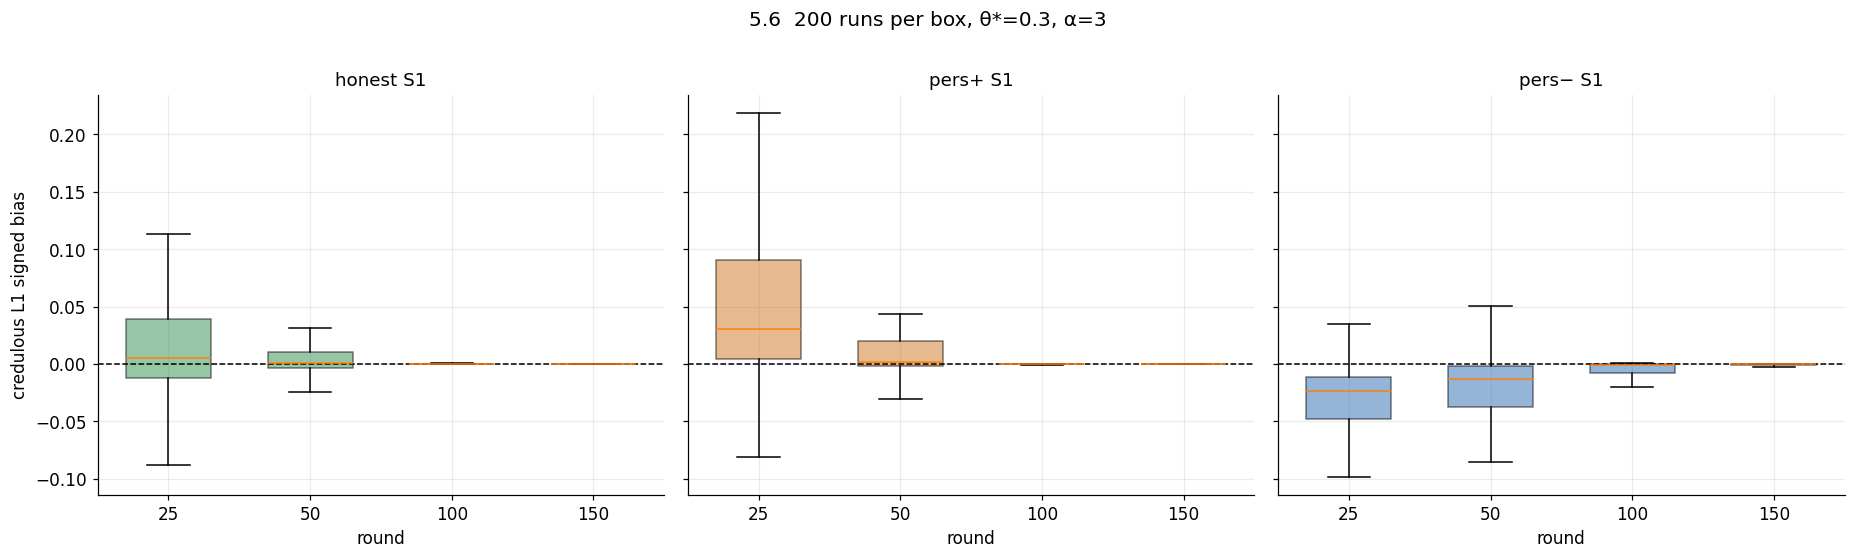

In [31]:
# 5.6 run-level spread of the terminal and mid-conversation belief
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for ax, psi in zip(axes, PSIS):
    data, labels = [], []
    for h in (25, 50, 100, 150):
        data.append(sel(RUS, psi_star=psi, alpha=FOCUS["alpha"], theta_star=FOCUS["theta"])[f"L1_bias_t{h}"].to_numpy()); labels.append(str(h))
    bp = ax.boxplot(data, labels=labels, showfliers=False, patch_artist=True, widths=0.6)
    for p in bp["boxes"]: p.set_facecolor(PSI_COL[psi]); p.set_alpha(0.5)
    ax.axhline(0, color="k", lw=1, ls="--"); ax.set_title(f"{PSI_LABEL[psi]} S1"); ax.set_xlabel("round")
axes[0].set_ylabel("credulous L1 signed bias")
fig.suptitle(f"5.6  200 runs per box, θ*={FOCUS['theta']:g}, α={FOCUS['alpha']:g}", y=1.01)
save_fig(fig, "B6_run_spread"); plt.show()

## 6. Cross-check: the sweep against switching study A

Same speaker (S1), same score (`sus1`), same detector rule, same world. Two
differences: the sweep's listener has an **11-point θ space with 0 and 1**
(study A: 9 points, 0.1–0.9), and the seeds differ, so the comparison is
between independent samples. Agreement validates both pipelines; the residual
is the θ-space effect.

overlapping alpha: [1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 7.0, 10.0] | overlapping c: [2.0, 3.0, 3.5, 4.0, 5.0]


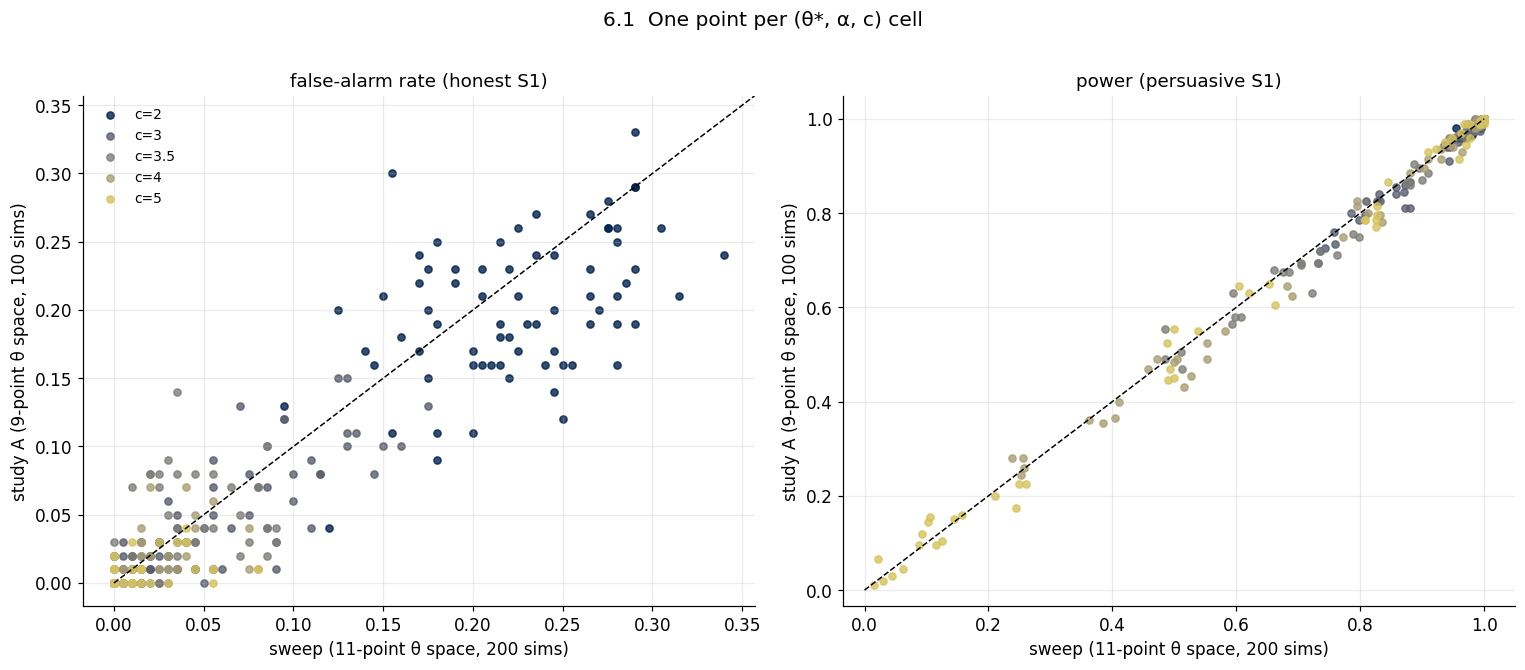

In [32]:
assert HAVE_SWITCH, "switching aggregates are needed for sections 6-8"
OVER_A = sorted(set(ALPHAS) & set(RW.alpha.unique()))
OVER_C = sorted(set(CS) & set(RW.c.unique()))
print("overlapping alpha:", OVER_A, "| overlapping c:", OVER_C)

def rates_A(keys, psi, c, horizon=None):
    t = sel(TAUW, study="A", switch_type="hard", c=c, psi_star=psi)
    t = t.assign(hit=((t.tau > 0) & ((t.tau <= horizon) if horizon else True)).astype(float))
    return t.groupby(keys, observed=True)["hit"].mean().reset_index(name="rate")

# 6.1 cell-by-cell agreement: false alarm and power, sweep vs A
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, psi, ttl in [(axes[0], "inf", "false-alarm rate (honest S1)"), (axes[1], ["high", "low"], "power (persuasive S1)")]:
    for c in OVER_C:
        s = rate_by(["theta_star", "alpha"], "sus1", c, psi_star=psi, alpha=OVER_A)
        a = rates_A(["theta_star", "alpha"], psi, c)
        m = s.merge(a, on=["theta_star", "alpha"], suffixes=("_sweep", "_A"))
        ax.scatter(m.rate_sweep, m.rate_A, s=22, color=CCOL[c], alpha=0.8, label=f"c={c:g}")
    lim = ax.get_xlim(); ax.plot([0, 1], [0, 1], "k--", lw=1); ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(ttl); ax.set_xlabel("sweep (11-point θ space, 200 sims)"); ax.set_ylabel("study A (9-point θ space, 100 sims)")
axes[0].legend(fontsize=9)
fig.suptitle("6.1  One point per (θ*, α, c) cell", y=1.01)
save_fig(fig, "X1_sweep_vs_A"); plt.show()

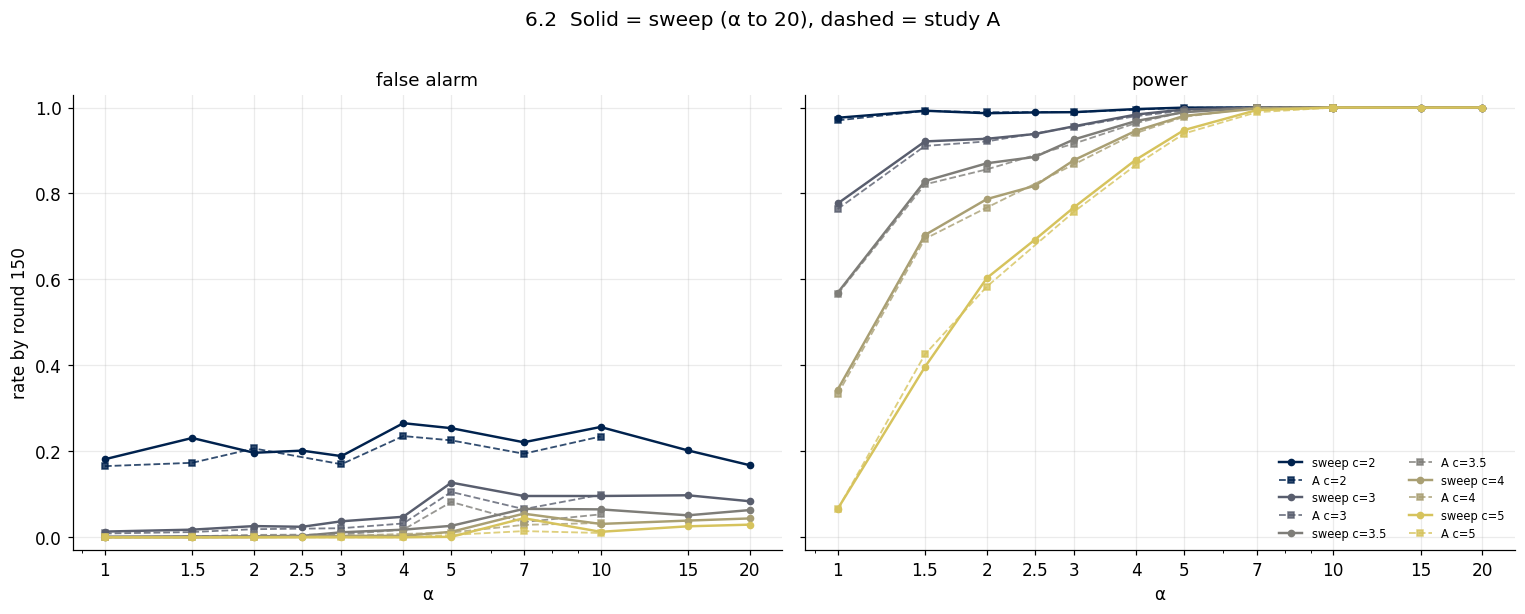

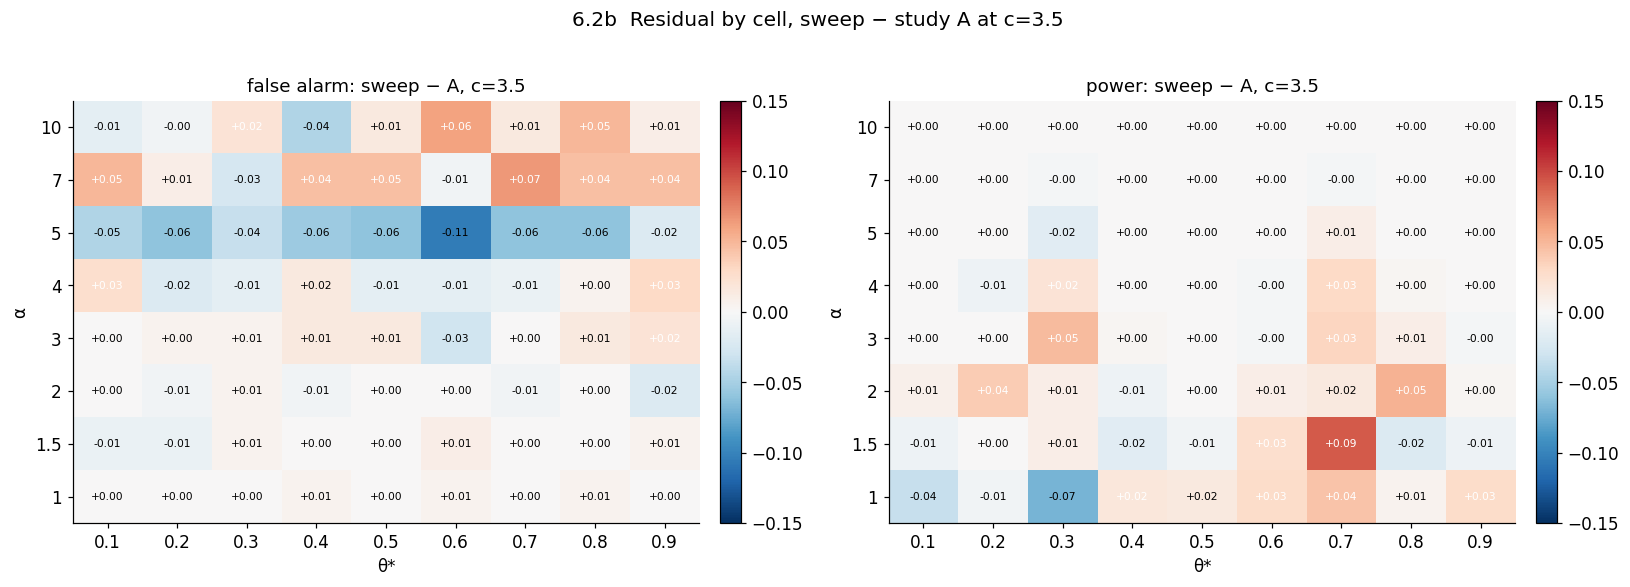

In [33]:
# 6.2 the same read against alpha, and the theta*-resolved residual
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, psi, ttl in [(axes[0], "inf", "false alarm"), (axes[1], ["high", "low"], "power")]:
    for c in OVER_C:
        s = rate_by(["alpha"], "sus1", c, psi_star=psi).sort_values("alpha")
        a = rates_A(["alpha"], psi, c).sort_values("alpha")
        ax.plot(s.alpha, s.rate, "o-", color=CCOL[c], lw=1.6, ms=4, label=f"sweep c={c:g}")
        ax.plot(a.alpha, a.rate, "s--", color=CCOL[c], lw=1.2, ms=4, alpha=0.8, label=f"A c={c:g}")
    alpha_axis(ax); ax.set_title(ttl); ax.set_ylim(-0.03, 1.03)
axes[0].set_ylabel("rate by round 150"); axes[1].legend(fontsize=7.5, ncol=2)
fig.suptitle("6.2  Solid = sweep (α to 20), dashed = study A", y=1.01)
save_fig(fig, "X2_rates_vs_alpha"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for ax, psi, ttl in [(axes[0], "inf", "false alarm"), (axes[1], ["high", "low"], "power")]:
    s = rate_by(["theta_star", "alpha"], "sus1", FOCUS["c"], psi_star=psi, alpha=OVER_A).pivot(index="alpha", columns="theta_star", values="rate")
    a = rates_A(["theta_star", "alpha"], psi, FOCUS["c"]).pivot(index="alpha", columns="theta_star", values="rate")
    D = (s - a).reindex(index=OVER_A)
    heat(ax, D.values, D.columns, D.index, "θ*", "α", f"{ttl}: sweep − A, c={FOCUS['c']:g}", cmap=CMAP_DIV, vmin=-0.15, vmax=0.15, fmt="{:+.2f}", fontsize=7)
fig.suptitle("6.2b  Residual by cell, sweep − study A at c=3.5", y=1.02)
save_fig(fig, "X3_residual_heat"); plt.show()

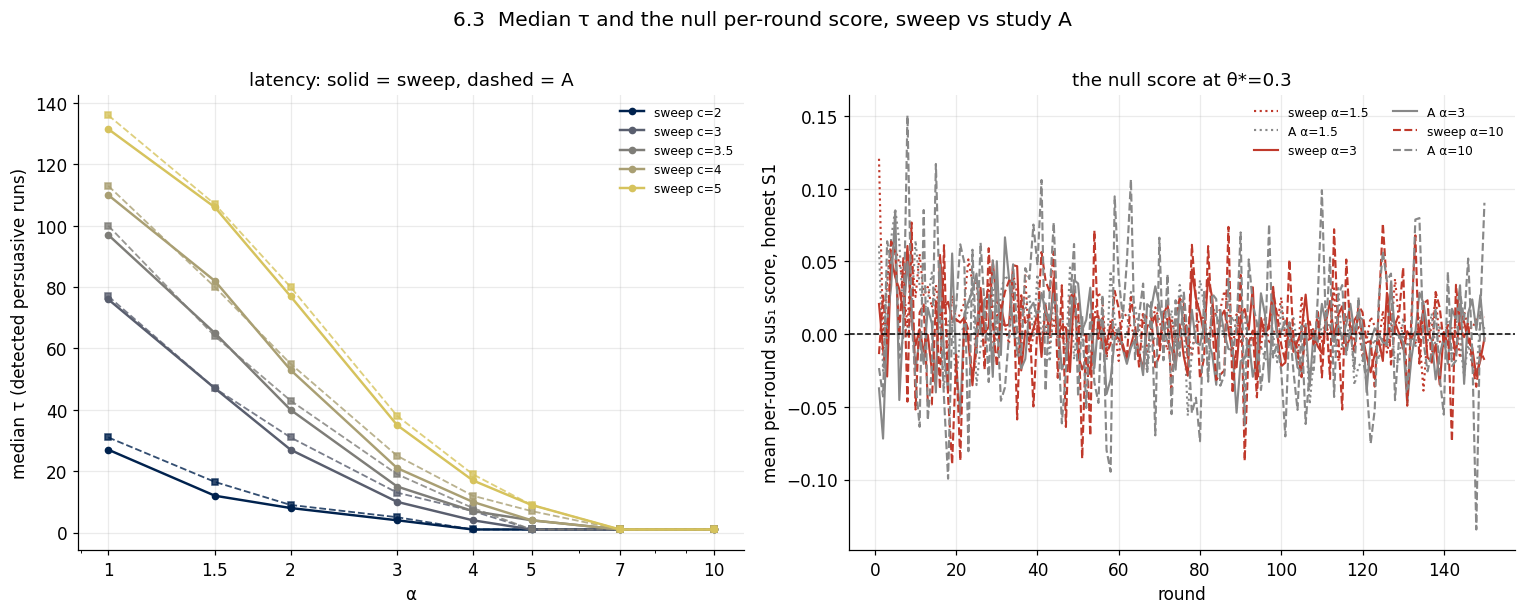

In [34]:
# 6.3 latency and the null score itself
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
ax = axes[0]
for c in OVER_C:
    s = sel(RUS, psi_star=["high", "low"], alpha=OVER_A); s = s[s[tau_col("sus1", c)] > 0].groupby("alpha")[tau_col("sus1", c)].median()
    a = sel(TAUW, study="A", switch_type="hard", c=c, psi_star=["high", "low"]); a = a[a.tau > 0].groupby("alpha")["tau"].median()
    ax.plot(s.index, s.values, "o-", color=CCOL[c], lw=1.6, ms=4, label=f"sweep c={c:g}")
    ax.plot(a.index, a.values, "s--", color=CCOL[c], lw=1.2, ms=4, alpha=0.8)
alpha_axis(ax, OVER_A); ax.set_ylabel("median τ (detected persuasive runs)"); ax.set_title("latency: solid = sweep, dashed = A"); ax.legend(fontsize=8)
ax = axes[1]
for a_, ls in [(1.5, ":"), (3.0, "-"), (10.0, "--")]:
    q = sel(RS, psi_star="inf", theta_star=FOCUS["theta"], alpha=a_).sort_values("round")
    ax.plot(q["round"], q.sus1_score, ls, color=COL["sweep"], lw=1.4, label=f"sweep α={a_:g}")
    w = sel(RW, study="A", psi_star="inf", theta_star=FOCUS["theta"], alpha=a_, c=2.0, switch_type="hard").sort_values("round")
    ax.plot(w["round"], w.sus1_score, ls, color=COL["A"], lw=1.4, label=f"A α={a_:g}")
ax.axhline(0, color="k", lw=1, ls="--"); ax.set_xlabel("round"); ax.set_ylabel("mean per-round sus₁ score, honest S1")
ax.set_title(f"the null score at θ*={FOCUS['theta']:g}"); ax.legend(fontsize=8, ncol=2)
fig.suptitle("6.3  Median τ and the null per-round score, sweep vs study A", y=1.01)
save_fig(fig, "X4_latency_null"); plt.show()

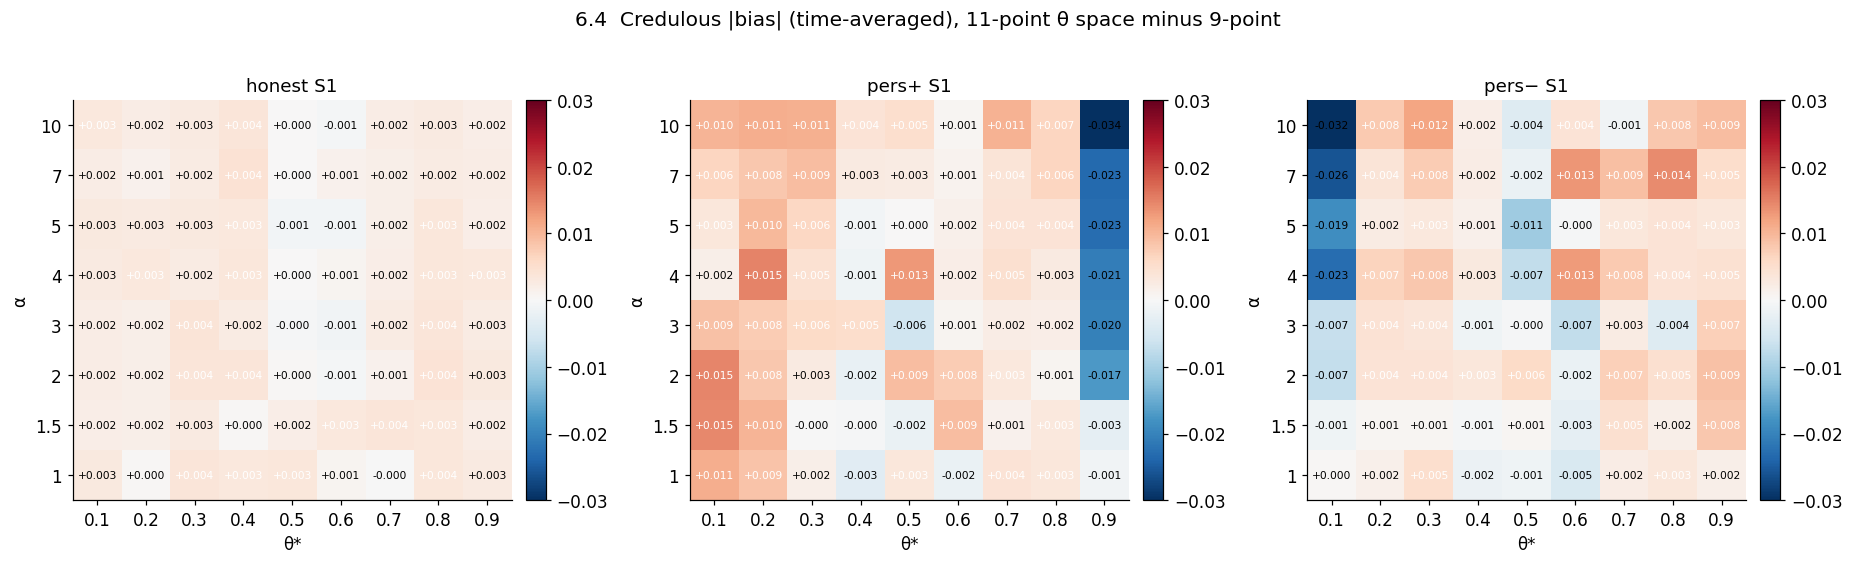

In [35]:
# 6.4 does the theta space change what the credulous listener learns?
# time-averaged |bias| of the credulous L1, sweep minus A, over (alpha, theta*)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, psi in zip(axes, PSIS):
    s = sel(RS, psi_star=psi, alpha=OVER_A).groupby(["alpha", "theta_star"])["L1_abias"].mean().unstack()
    a = sel(RW, study="A", psi_star=psi, c=2.0, switch_type="hard").groupby(["alpha", "theta_star"])["abias_cred"].mean().unstack()
    D = s - a
    heat(ax, D.values, D.columns, D.index, "θ*", "α", f"{PSI_LABEL[psi]} S1", cmap=CMAP_DIV, vmin=-0.03, vmax=0.03, fmt="{:+.3f}", fontsize=7)
fig.suptitle("6.4  Credulous |bias| (time-averaged), 11-point θ space minus 9-point", y=1.02)
save_fig(fig, "X5_theta_space_bias"); plt.show()

## 7. The speaker-level ladder: S1 → S2

The detector's null is "an informative **S1**". The sweep and study A show how
it behaves when that is literally true; study B shows what happens when the
honest speaker is an **S2** with an exact model of the switching listener. The
sweep adds α = 15 and 20 to the S1 baseline.

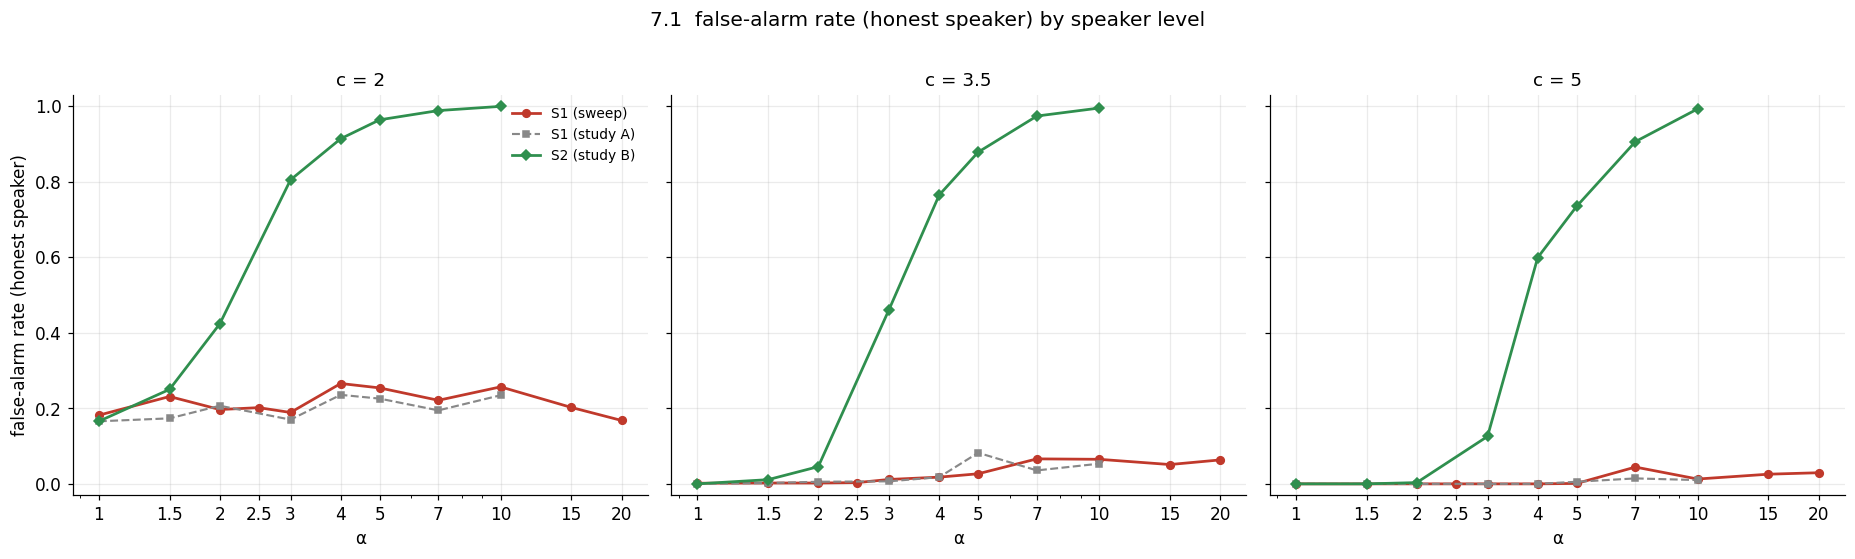

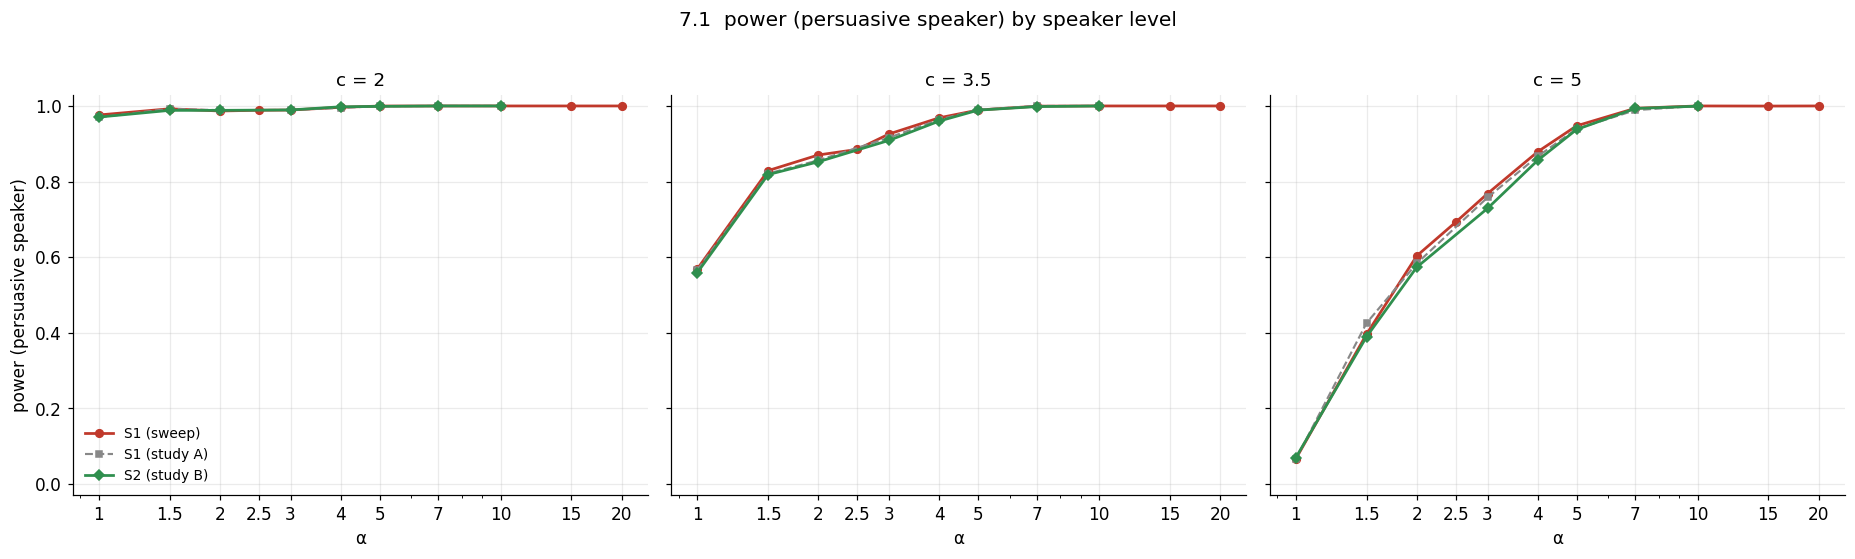

In [36]:
def rates_B(keys, psi, c, st="hard"):
    t = sel(TAUW, study="B", switch_type=st, c=c, psi_star=psi)
    return t.assign(hit=(t.tau > 0).astype(float)).groupby(keys, observed=True)["hit"].mean().reset_index(name="rate")

# 7.1 false alarm and power against alpha, three datasets, three boundaries
for psi, ttl, fn in [("inf", "false-alarm rate (honest speaker)", "L1_fa_ladder"), (["high", "low"], "power (persuasive speaker)", "L2_power_ladder")]:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
    for ax, c in zip(axes, [2.0, 3.5, 5.0]):
        s = rate_by(["alpha"], "sus1", c, psi_star=psi).sort_values("alpha")
        a = rates_A(["alpha"], psi, c).sort_values("alpha")
        b = rates_B(["alpha"], psi, c).sort_values("alpha")
        ax.plot(s.alpha, s.rate, "o-", color=COL["sweep"], lw=1.8, ms=5, label="S1 (sweep)")
        ax.plot(a.alpha, a.rate, "s--", color=COL["A"], lw=1.4, ms=4, label="S1 (study A)")
        ax.plot(b.alpha, b.rate, "D-", color=COL["B"], lw=1.8, ms=5, label="S2 (study B)")
        alpha_axis(ax); ax.set_ylim(-0.03, 1.03); ax.set_title(f"c = {c:g}")
    axes[0].set_ylabel(ttl); axes[0].legend(fontsize=9)
    fig.suptitle(f"7.1  {ttl} by speaker level", y=1.01)
    save_fig(fig, fn); plt.show()

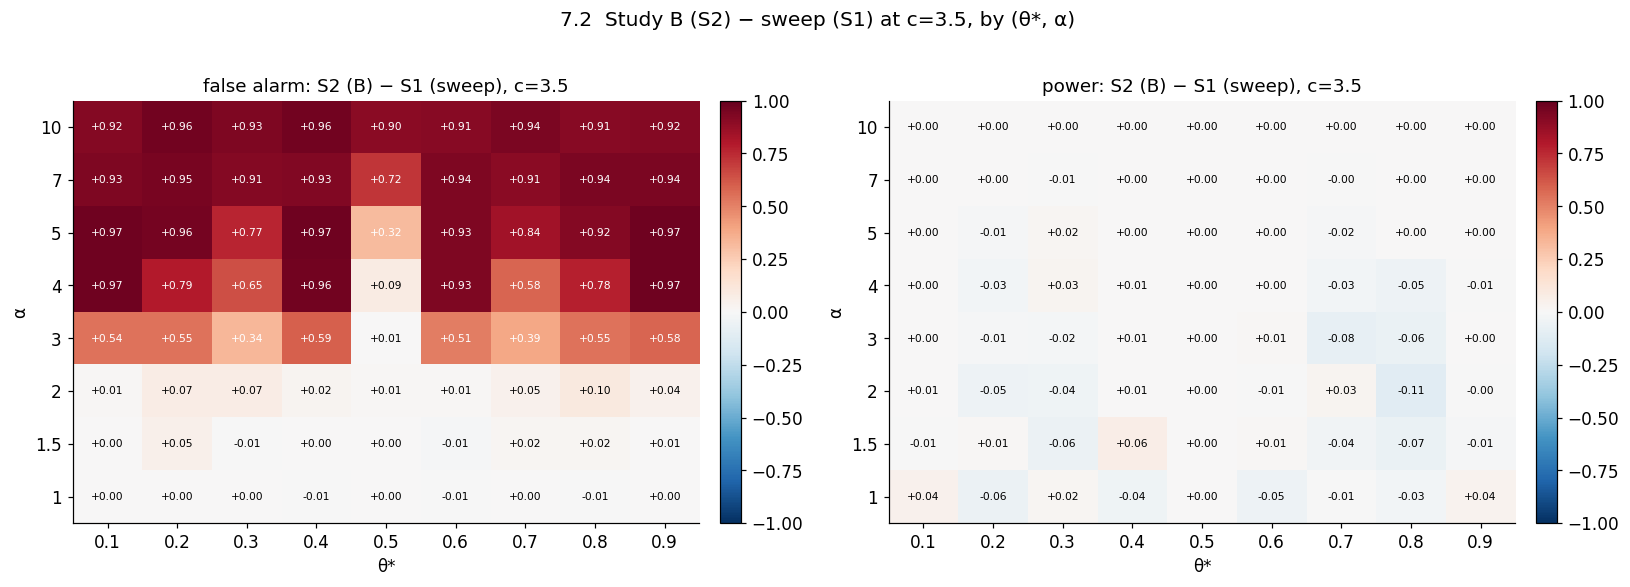

In [37]:
# 7.2 where in (theta*, alpha) the level-2 speaker changes the picture
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for ax, psi, ttl in [(axes[0], "inf", "false alarm"), (axes[1], ["high", "low"], "power")]:
    s = rate_by(["theta_star", "alpha"], "sus1", FOCUS["c"], psi_star=psi, alpha=OVER_A).pivot(index="alpha", columns="theta_star", values="rate")
    b = rates_B(["theta_star", "alpha"], psi, FOCUS["c"]).pivot(index="alpha", columns="theta_star", values="rate")
    D = (b - s).reindex(index=OVER_A)
    heat(ax, D.values, D.columns, D.index, "θ*", "α", f"{ttl}: S2 (B) − S1 (sweep), c={FOCUS['c']:g}", cmap=CMAP_DIV, vmin=-1, vmax=1, fmt="{:+.2f}", fontsize=7)
fig.suptitle("7.2  Study B (S2) − sweep (S1) at c=3.5, by (θ*, α)", y=1.02)
save_fig(fig, "L3_level_residual"); plt.show()

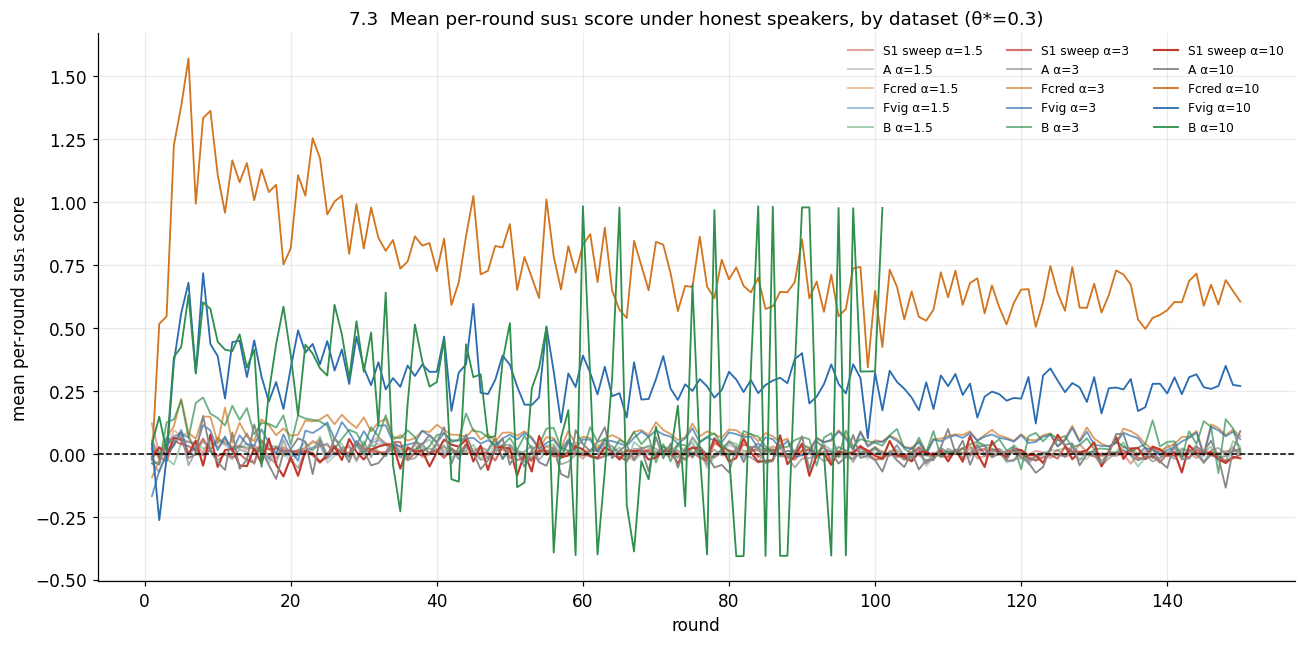

In [38]:
# 7.3 the honest per-round score by speaker level and audience
fig, ax = plt.subplots(figsize=(12, 6))
for a_, alph in [(1.5, 0.45), (3.0, 0.7), (10.0, 1.0)]:
    q = sel(RS, psi_star="inf", theta_star=FOCUS["theta"], alpha=a_).sort_values("round")
    ax.plot(q["round"], q.sus1_score, color=COL["sweep"], lw=1.4, alpha=alph, label=f"S1 sweep α={a_:g}")
    for st in ("A", "Fcred", "Fvig", "B"):
        w = sel(RW, study=st, psi_star="inf", theta_star=FOCUS["theta"], alpha=a_, c=2.0, switch_type="hard").sort_values("round")
        ax.plot(w["round"], w.sus1_score, color=COL[st], lw=1.2, alpha=alph, label=f"{st} α={a_:g}")
ax.axhline(0, color="k", lw=1, ls="--")
finish(ax, f"7.3  Mean per-round sus₁ score under honest speakers, by dataset (θ*={FOCUS['theta']:g})",
       "round", "mean per-round sus₁ score", ncol=3, fontsize=8, save_as="L4_null_score_by_level")
plt.show()

## 8. Damage before detection: S1 vs S2 persuaders

How far had the credulous listener been pushed by the time the alarm fired?
Sweep: L1 bias at τ−1 for the fixed-z rule (from the stored posteriors);
study B: the counterfactual credulous listener's bias at τ−1 on the S2 stream.

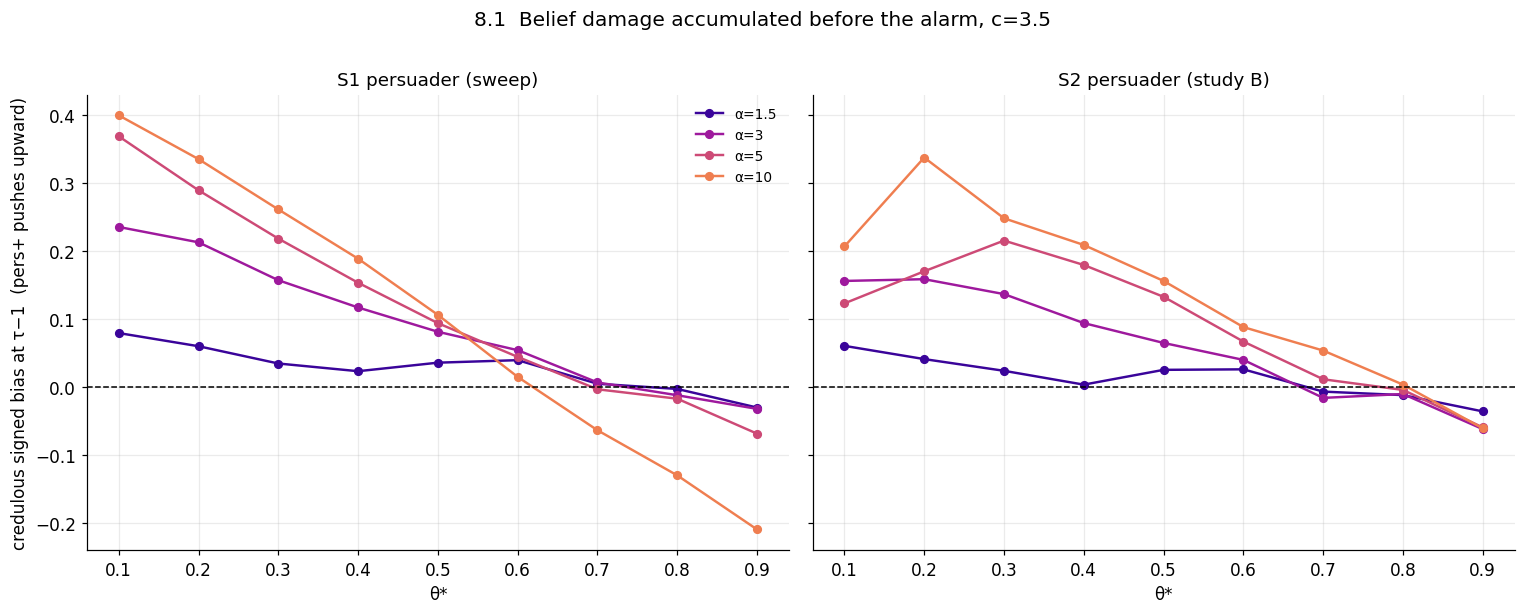

In [39]:
# 8.1 mean damage against theta*, by alpha, at the focus c
c = FOCUS["c"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, (lab, getter) in zip(axes, [("S1 persuader (sweep)", None), ("S2 persuader (study B)", None)]):
    for a_ in [1.5, 3.0, 5.0, 10.0]:
        if lab.startswith("S1"):
            d = sel(RUS, psi_star="high", alpha=a_); q = d.groupby("theta_star")[f"dmg_sus1_c{c:g}"].mean()
        else:
            d = sel(RUW, study="B", psi_star="high", alpha=a_, c=c, switch_type="hard", horizon="tau_minus_1"); q = d.groupby("theta_star")["bias_cred"].mean()
        ax.plot(q.index, q.values, "o-", color=ACOL[a_], lw=1.6, ms=5, label=f"α={a_:g}")
    ax.axhline(0, color="k", lw=1, ls="--"); ax.set_title(lab); ax.set_xlabel("θ*")
axes[0].set_ylabel("credulous signed bias at τ−1  (pers+ pushes upward)"); axes[0].legend(fontsize=9)
fig.suptitle(f"8.1  Belief damage accumulated before the alarm, c={c:g}", y=1.01)
save_fig(fig, "G1_damage_vs_theta"); plt.show()

**Caveat on 8.1.** Bias at τ−1 mixes two things: what the persuader did, and
how far the listener's prior (mean 0.5) still had to travel by round τ−1. When
the alarm fires at τ ≈ 1–2 (high α) the second term dominates — hence the
negative "damage" for a pers+ speaker at θ\* = 0.9. The next figure removes it:
**excess damage** = bias at τ−1 minus the mean credulous bias an *honest*
speaker produces at that same round (same θ\*, α).

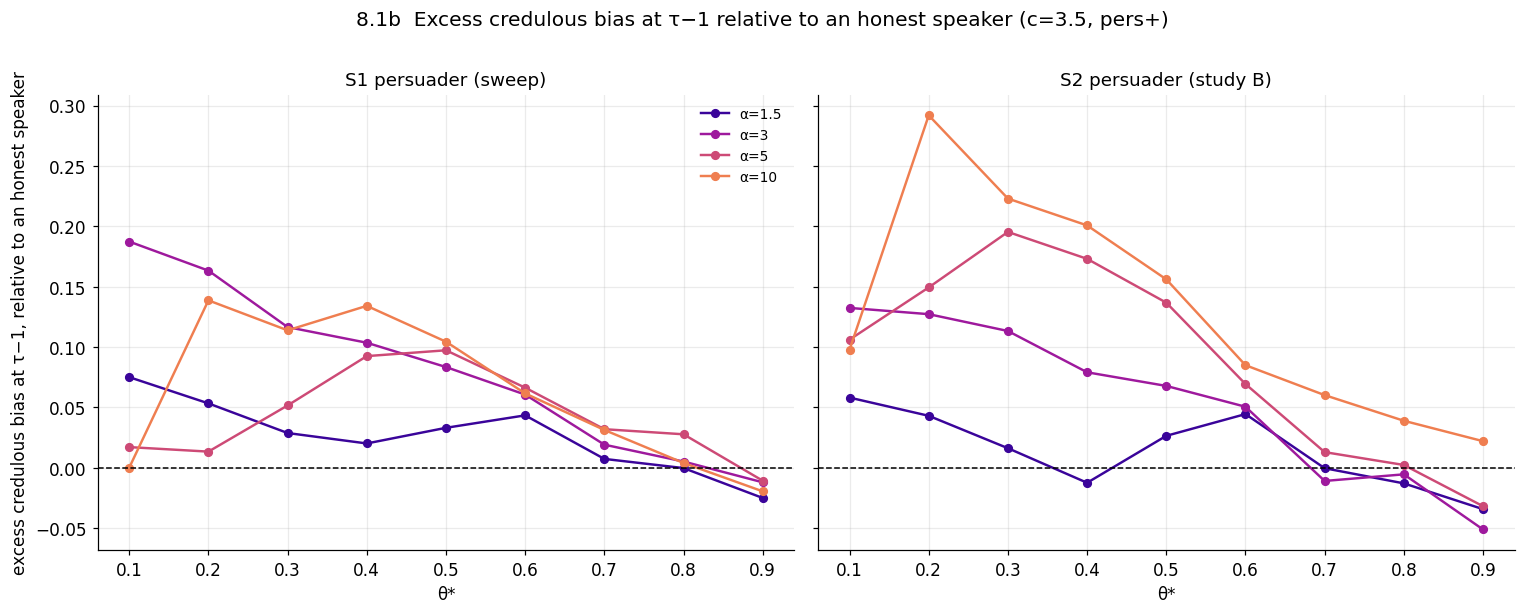

mean excess damage in the persuader's direction, averaged over theta* (c=3.5):


,S1 pers+,S2 pers+,S1 pers−,S2 pers−
alpha,,,,
1.0,0.0100,0.0061,0.0118,0.0124
1.5,0.0262,0.0142,0.0267,0.0160
2.0,0.0449,0.0295,0.0438,0.0332
2.5,0.0665,NaN,0.0676,NaN
3.0,0.0807,0.0558,0.0792,0.0572
4.0,0.0668,0.0578,0.0652,0.0610
5.0,0.0430,0.0903,0.0466,0.0610
7.0,0.1690,0.0916,0.1473,0.1045
10.0,0.0631,0.1306,0.1051,0.1365


In [40]:
# 8.1b excess damage: bias at tau-1 relative to the honest-speaker baseline at the same round
def honest_baseline(source, theta, alpha):
    if source == "S1":
        q = sel(RS, psi_star="inf", theta_star=theta, alpha=alpha).set_index("round")["L1_bias"]
    else:
        q = sel(RW, study="B", psi_star="inf", theta_star=theta, alpha=alpha, c=c, switch_type="hard").set_index("round")["bias_cred"]
    return q.reindex(ROUNDS).to_numpy()

def excess_damage(source, psi, alpha):
    out = {}
    for th in THETAS:
        if source == "S1":
            d = sel(RUS, psi_star=psi, theta_star=th, alpha=alpha); tau = d[tau_col("sus1", c)].to_numpy(); dmg = d[f"dmg_sus1_c{c:g}"].to_numpy()
        else:
            d = sel(RUW, study="B", psi_star=psi, theta_star=th, alpha=alpha, c=c, switch_type="hard", horizon="tau_minus_1"); tau = d.tau.to_numpy(); dmg = d.bias_cred.to_numpy()
        ok = (tau > 1) & np.isfinite(dmg)
        if not ok.any():
            out[th] = np.nan; continue
        base = honest_baseline(source, th, alpha)[tau[ok] - 2]      # honest credulous bias at round tau-1
        out[th] = float(np.mean(dmg[ok] - base))
    return pd.Series(out)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, src, lab in [(axes[0], "S1", "S1 persuader (sweep)"), (axes[1], "S2", "S2 persuader (study B)")]:
    for a_ in [1.5, 3.0, 5.0, 10.0]:
        e = excess_damage(src, "high", a_)
        ax.plot(e.index, e.values, "o-", color=ACOL[a_], lw=1.6, ms=5, label=f"\u03b1={a_:g}")
    ax.axhline(0, color="k", lw=1, ls="--"); ax.set_title(lab); ax.set_xlabel("\u03b8*")
axes[0].set_ylabel("excess credulous bias at \u03c4\u22121, relative to an honest speaker"); axes[0].legend(fontsize=9)
fig.suptitle(f"8.1b  Excess credulous bias at τ−1 relative to an honest speaker (c={c:g}, pers+)", y=1.01)
save_fig(fig, "G1b_excess_damage"); plt.show()

rows = []
for a_ in ALPHAS:
    r = dict(alpha=a_)
    for psi, sign in [("high", 1), ("low", -1)]:
        r[f"S1 {PSI_LABEL[psi]}"] = sign * excess_damage("S1", psi, a_).mean()
        if a_ in OVER_A:
            r[f"S2 {PSI_LABEL[psi]}"] = sign * excess_damage("S2", psi, a_).mean()
    rows.append(r)
print(f"mean excess damage in the persuader's direction, averaged over theta* (c={c:g}):")
display(pd.DataFrame(rows).set_index("alpha").round(4))

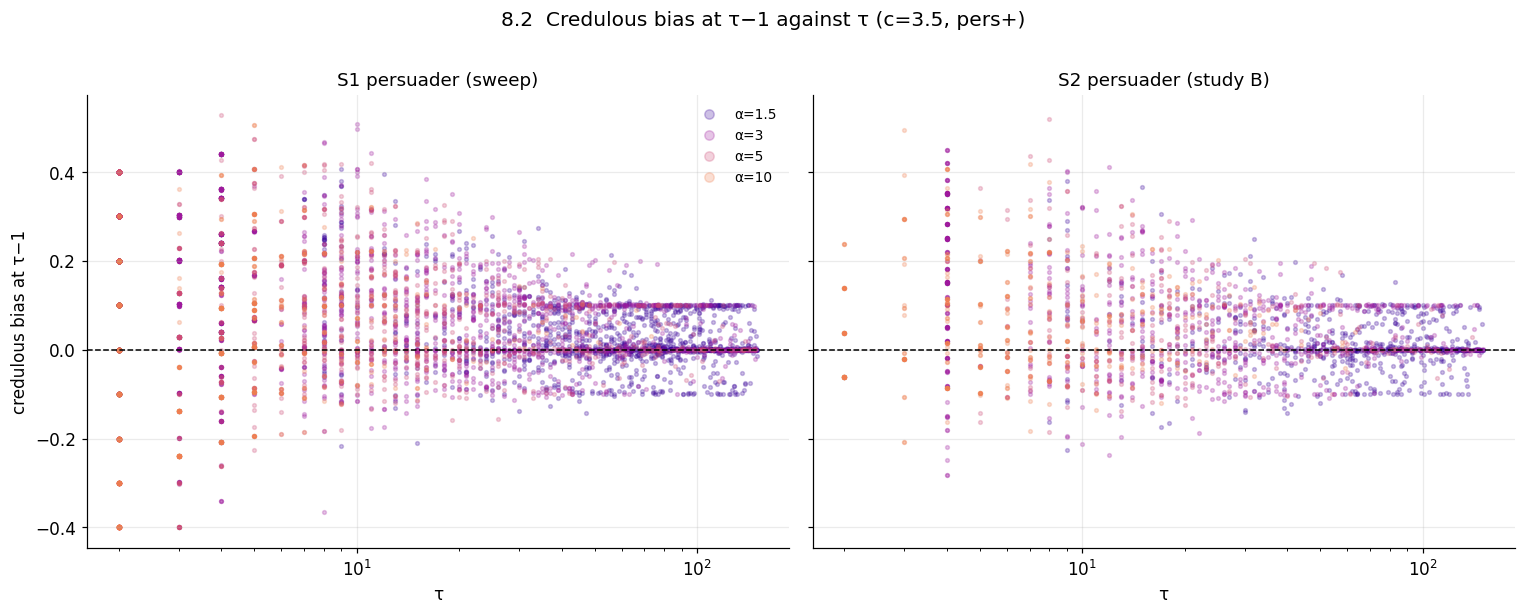

mean damage at tau-1 in the persuader's direction (c=3.5; NaN where the alarm never fired or fired at tau=1):


,S1 pers+,S2 pers+,S1 pers−,S2 pers−
alpha,,,,
1.0,0.0108,0.0049,0.0115,0.0142
1.5,0.0278,0.0146,0.0275,0.0180
2.0,0.0471,0.0316,0.0478,0.0350
2.5,0.0756,NaN,0.0757,NaN
3.0,0.0957,0.0668,0.0953,0.0605
4.0,0.1131,0.0890,0.1123,0.0805
5.0,0.1209,0.0417,0.1195,0.0242
7.0,0.0270,0.0458,0.0316,0.0340
10.0,-0.0501,0.0580,-0.0480,0.0412


In [41]:
# 8.2 damage against when the alarm came
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, lab in zip(axes, ["S1 persuader (sweep)", "S2 persuader (study B)"]):
    for a_ in [1.5, 3.0, 5.0, 10.0]:
        if lab.startswith("S1"):
            d = sel(RUS, psi_star="high", alpha=a_); x, y = d[tau_col("sus1", c)], d[f"dmg_sus1_c{c:g}"]
        else:
            d = sel(RUW, study="B", psi_star="high", alpha=a_, c=c, switch_type="hard", horizon="tau_minus_1"); x, y = d.tau, d.bias_cred
        ok = (x > 1) & y.notna()
        ax.scatter(x[ok], y[ok], s=6, alpha=0.25, color=ACOL[a_], label=f"α={a_:g}")
    ax.axhline(0, color="k", lw=1, ls="--"); ax.set_xscale("log"); ax.set_title(lab); ax.set_xlabel("τ")
axes[0].set_ylabel("credulous bias at τ−1"); axes[0].legend(fontsize=9, markerscale=2.5)
fig.suptitle(f"8.2  Credulous bias at τ−1 against τ (c={c:g}, pers+)", y=1.01)
save_fig(fig, "G2_damage_vs_tau"); plt.show()

rows = []
for a_ in ALPHAS:
    r = dict(alpha=a_)
    for psi, sign in [("high", 1), ("low", -1)]:
        d = sel(RUS, psi_star=psi, alpha=a_)[f"dmg_sus1_c{c:g}"]; r[f"S1 {PSI_LABEL[psi]}"] = sign * d.mean()
        if a_ in OVER_A:
            w = sel(RUW, study="B", psi_star=psi, alpha=a_, c=c, switch_type="hard", horizon="tau_minus_1")["bias_cred"]; r[f"S2 {PSI_LABEL[psi]}"] = sign * w.mean()
    rows.append(r)
print(f"mean damage at tau-1 in the persuader's direction (c={c:g}; NaN where the alarm never fired or fired at tau=1):")
display(pd.DataFrame(rows).set_index("alpha").round(4))

## 9. Summary tables

In [42]:
# 9.1 the fixed-z operating table, both scores, all c (all alpha)
display(HL.round(3).pivot(index="c", columns="score", values=["false_alarm", "power_pers_plus", "power_pers_minus", "youden"]))
print("\nusable cells (false alarm <= 0.05 and power >= 0.80) by (score, alpha, c):")
rows = []
for sc in SCORES:
    for a in ALPHAS:
        for cc in CS:
            fa, pw = fa_power(sc, cc, alpha=a)
            if fa <= 0.05 and pw >= 0.80:
                rows.append(dict(score=SCORE_SHORT[sc], alpha=a, c=cc, false_alarm=round(fa, 3), power=round(pw, 3)))
display(pd.DataFrame(rows).to_string(index=False) if rows else "none")

false_alarm        power_pers_plus        power_pers_minus        youden       
score       surp2   sus₁           surp2   sus₁            surp2   sus₁  surp2   sus₁
c                                                                                    
2.0         0.233  0.215           0.681  0.994            0.678  0.993  0.446  0.778
2.5         0.121  0.121           0.639  0.981            0.640  0.980  0.518  0.860
3.0         0.069  0.061           0.608  0.956            0.610  0.953  0.539  0.894
3.5         0.035  0.028           0.579  0.912            0.579  0.913  0.544  0.884
4.0         0.020  0.017           0.552  0.859            0.553  0.860  0.533  0.842
5.0         0.006  0.010           0.507  0.760            0.509  0.758  0.502  0.748


usable cells (false alarm <= 0.05 and power >= 0.80) by (score, alpha, c):


'score  alpha   c  false_alarm  power\nsurp2    7.0 3.5        0.035  0.890\nsurp2    7.0 4.0        0.008  0.874\nsurp2    7.0 5.0        0.001  0.842\nsurp2   10.0 3.5        0.041  0.971\nsurp2   10.0 4.0        0.027  0.960\nsurp2   10.0 5.0        0.007  0.940\nsurp2   15.0 3.5        0.031  0.999\nsurp2   15.0 4.0        0.018  0.998\nsurp2   15.0 5.0        0.003  0.991\nsurp2   20.0 3.5        0.042  1.000\nsurp2   20.0 4.0        0.020  1.000\nsurp2   20.0 5.0        0.002  1.000\n sus₁    1.5 3.0        0.018  0.921\n sus₁    1.5 3.5        0.002  0.829\n sus₁    2.0 3.0        0.026  0.927\n sus₁    2.0 3.5        0.002  0.870\n sus₁    2.5 3.0        0.024  0.938\n sus₁    2.5 3.5        0.003  0.885\n sus₁    2.5 4.0        0.001  0.818\n sus₁    3.0 3.0        0.037  0.956\n sus₁    3.0 3.5        0.012  0.926\n sus₁    3.0 4.0        0.003  0.878\n sus₁    4.0 3.0        0.048  0.984\n sus₁    4.0 3.5        0.018  0.969\n sus₁    4.0 4.0        0.003  0.946\n sus₁    4.

In [43]:
# 9.2 stopping rules at matched false-alarm rate (from 4.6) and the ladder headline
display(R2[["score", "rule", "param", "FPR_heldout", "power", "median_tau", "alpha_spread", "controls_FPR"]].round(3))
if HAVE_SWITCH:
    rows = []
    for a in OVER_A:
        fa_s, pw_s = fa_power("sus1", FOCUS["c"], alpha=a)
        fa_b = rates_B(["alpha"], "inf", FOCUS["c"]); pw_b = rates_B(["alpha"], ["high", "low"], FOCUS["c"])
        rows.append(dict(alpha=a, S1_false_alarm=fa_s, S1_power=pw_s,
                         S2_false_alarm=float(fa_b[fa_b.alpha == a].rate.iloc[0]), S2_power=float(pw_b[pw_b.alpha == a].rate.iloc[0])))
    print(f"\nlevel ladder at c={FOCUS['c']:g}:")
    display(pd.DataFrame(rows).set_index("alpha").round(3))

,score,rule,param,FPR_heldout,power,median_tau,alpha_spread,controls_FPR
0,surp2,fixed_z,3.341,0.042,0.646,4.0,0.041,True
1,surp2,warm-up t≥10,2.868,0.051,0.665,10.0,0.026,True
2,surp2,LIL,4.912,0.046,0.516,2.0,0.047,True
3,surp2,Robbins,0.409,0.053,0.669,10.0,0.058,True
4,sus₁,fixed_z,3.275,0.049,0.959,4.0,0.106,True
5,sus₁,warm-up t≥10,2.790,0.052,0.979,10.0,0.058,True
6,sus₁,LIL,5.916,0.046,0.647,1.0,0.148,True
7,sus₁,Robbins,0.421,0.051,0.930,11.0,0.056,True



level ladder at c=3.5:


,S1_false_alarm,S1_power,S2_false_alarm,S2_power
alpha,,,,
1.0,0.002,0.569,0.000,0.559
1.5,0.002,0.829,0.011,0.818
2.0,0.002,0.870,0.046,0.852
3.0,0.012,0.926,0.461,0.909
4.0,0.018,0.969,0.764,0.960
5.0,0.027,0.989,0.878,0.989
7.0,0.066,0.999,0.973,0.998
10.0,0.065,1.000,0.994,1.000


---

### Reproducing / extending

* `python experiments/full_sweep/aggregate.py` rebuilds `results/full_sweep_v2/agg/`
  (~10 s); `python experiments/switching/aggregate.py` rebuilds the switching side.
* `FOCUS` in §0 re-aims the single-configuration figures; `SAVE = True` writes
  every figure to `results/full_sweep_v2/figures/`.
* `load_sweep_cell(theta_star, psi_star, alpha)` returns raw per-round rows,
  including the full L1/L0 posteriors, for any cell.
* New stopping rules: add a boundary `B(t, V_t)` next to the ones in §4 and
  pass it to `evaluate`; everything else (rates, latency, calibration) follows.